In [53]:
from pathlib import Path
import json
import datetime
import re
import hashlib
import os
import pickle as pkl

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.stats import skew, kurtosis
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu
from statsmodels.stats.diagnostic import lilliefors
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif, SequentialFeatureSelector
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from tqdm.auto import tqdm
from sklearn.utils import resample

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_score, recall_score,
    f1_score, make_scorer, get_scorer
)

In [2]:
root = Path('..')
data = Path('data')
dataframe = Path('clean_data.pkl')

df = pd.read_pickle(root/data/dataframe)

# Create new variables

the new ones are based completely in data before the relase and the target variable takes only 90 days before the realese

In [3]:
# ============================================================
# 1. PARÁMETROS (ajustables)
# ============================================================
HORIZON_DAYS = 90          # horizonte fijo post-release para el target
MIN_YEAR = 2017             # descarta años con muy poco volumen
RARE_BRAND_THRESHOLD = 80  # marcas con menos registros que esto -> 'Other'

# ============================================================
# 2. TARGET (horizonte fijo) + FEATURES PRE-RELEASE
#    Se parsea sales_series UNA sola vez por fila
# ============================================================
def construir_target_y_features(row):
    serie = row['sales_series']
    release_date = row['release_date']
    retail_price = row['retail_price']

    vacio = {
        'is_above_retail_90d': np.nan,
        'value_at_horizon': np.nan,
        'pre_release_peak': 0,
        'pre_release_premium_pct': 0,
        'has_pre_release_speculation': False,
        'num_pre_release_points': 0,
        'pre_release_volatility': 0,
        'pre_release_trend': 0,
        'days_speculation_window': 0,
    }

    if not serie:
        return pd.Series(vacio)

    serie_df = pd.DataFrame(serie)
    serie_df['xValue'] = pd.to_datetime(serie_df['xValue'], utc=True).dt.tz_localize(None)
    serie_df = serie_df.sort_values('xValue').reset_index(drop=True)

    # --- TARGET: precio más cercano a release_date + HORIZON_DAYS ---
    fecha_horizonte = release_date + pd.Timedelta(days=HORIZON_DAYS)
    post = serie_df[serie_df['xValue'] >= release_date]
    candidatos_horizonte = post[post['xValue'] <= fecha_horizonte]

    if not candidatos_horizonte.empty:
        # punto disponible más cercano al horizonte (sin mirar después de él)
        idx_cercano = (fecha_horizonte - candidatos_horizonte['xValue']).idxmin()
        value_at_horizon = serie_df.loc[idx_cercano, 'yValue']
        is_above = bool(value_at_horizon > retail_price) if retail_price else False
    else:
        # aún no pasó suficiente tiempo desde el lanzamiento -> sin target válido
        value_at_horizon = np.nan
        is_above = np.nan

    # --- FEATURES PRE-RELEASE (solo datos ANTES de release_date) ---
    pre = serie_df[serie_df['xValue'] < release_date]

    if not pre.empty:
        pre_release_peak = pre['yValue'].max()
        pre_release_premium_pct = (
            (pre_release_peak - retail_price) / retail_price * 100 if retail_price else 0
        )
        has_pre_release_speculation = True
        num_pre_release_points = len(pre)
        pre_release_volatility = pre['yValue'].std()
        if pd.isna(pre_release_volatility):
            pre_release_volatility = 0

        # tendencia: pendiente de yValue ~ días transcurridos (regresión lineal simple)
        dias = (pre['xValue'] - pre['xValue'].min()).dt.days.values
        if len(dias) >= 2 and np.ptp(dias) > 0:
            pre_release_trend = np.polyfit(dias, pre['yValue'].values, 1)[0]
        else:
            pre_release_trend = 0

        days_speculation_window = (release_date - pre['xValue'].min()).days
    else:
        pre_release_peak = 0
        pre_release_premium_pct = 0
        has_pre_release_speculation = False
        num_pre_release_points = 0
        pre_release_volatility = 0
        pre_release_trend = 0
        days_speculation_window = 0

    return pd.Series({
        'is_above_retail_90d': is_above,
        'value_at_horizon': value_at_horizon,
        'pre_release_peak': pre_release_peak,
        'pre_release_premium_pct': pre_release_premium_pct,
        'has_pre_release_speculation': has_pre_release_speculation,
        'num_pre_release_points': num_pre_release_points,
        'pre_release_volatility': pre_release_volatility,
        'pre_release_trend': pre_release_trend,
        'days_speculation_window': days_speculation_window,
    })

nuevas_cols = df.apply(construir_target_y_features, axis=1)
df[nuevas_cols.columns] = nuevas_cols

# ============================================================
# 3. FEATURES DE FECHA (estacionalidad)
# ============================================================
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['release_quarter'] = df['release_date'].dt.quarter
df['release_dow'] = df['release_date'].dt.dayofweek

# ============================================================
# 4. HISTORIAL DE MARCA — ventana EXPANSIVA, sin leakage
#    % de pares de esa marca que estuvieron por encima del retail,
#    usando SOLO lanzamientos anteriores a la fecha de esta fila
# ============================================================
df = df.sort_values('release_date').reset_index(drop=True)

def historial_marca_expansivo(df):
    resultado = pd.Series(index=df.index, dtype=float)
    for marca, grupo in df.groupby('brand'):
        grupo = grupo.sort_values('release_date')
        expanding_mean = grupo['is_above_retail_90d'].expanding().mean().shift(1)
        resultado.loc[grupo.index] = expanding_mean
    return resultado

df['brand_historical_rate'] = historial_marca_expansivo(df)
# fallback para el primer lanzamiento de cada marca (sin historial propio):
# tasa global expansiva hasta ese punto
tasa_global_expansiva = df['is_above_retail_90d'].expanding().mean().shift(1)
df['brand_historical_rate'] = df['brand_historical_rate'].fillna(tasa_global_expansiva).fillna(0)

# ============================================================
# 5. FEATURES DE TÍTULO
# ============================================================
df['title_length'] = df['title'].str.len()
df['is_collab'] = df['title'].str.contains(
    r'\sx\s|collab|collaboration', case=False, regex=True, na=False
)
df['is_special_edition'] = df['title'].str.contains(
    r'\bOG\b|retro|limited|exclusive', case=False, regex=True, na=False
)

# ============================================================
# 6. AGRUPAR MARCAS RARAS
# ============================================================
conteo_marcas = df['brand'].value_counts()
marcas_raras = conteo_marcas[conteo_marcas < RARE_BRAND_THRESHOLD].index
df['brand_grouped'] = df['brand'].where(~df['brand'].isin(marcas_raras), 'Other')

# ============================================================
# 7. DATASET FINAL PARA MODELAR
#    descarta años con poco volumen y filas sin target válido
#    (pares demasiado recientes que no llegan a los 90 días)
# ============================================================
df_modelo = df[
    (df['release_date'].dt.year >= MIN_YEAR) &
    (df['is_above_retail_90d'].notna())
].copy()

print(f"Filas totales: {len(df)}")
print(f"Filas aptas para modelar: {len(df_modelo)}")
print(df_modelo['is_above_retail_90d'].value_counts(normalize=True))
print(df_modelo['brand_grouped'].value_counts())

Filas totales: 4819
Filas aptas para modelar: 4089
is_above_retail_90d
True     0.503057
False    0.496943
Name: proportion, dtype: float64
brand_grouped
Nike           808
Jordan         797
New Balance    723
Puma           590
ASICS          514
Adidas         470
Yeezy          155
Onitsuka        31
Other            1
Name: count, dtype: int64


# Variable Dictionary — Modeling Dataset (df_modelo)

| Variable | Type | Role | Description |
|---|---|---|---|
| `title` | string | Reference only | Sneaker title/name. Kept for traceability, not fed into the model. |
| `retail_price` | float | Feature | Official retail (launch) price. |
| `release_date` | datetime | Reference only | Official release date. Kept for traceability; its useful signal is already extracted into `release_year`, `release_month`, `release_quarter`, `release_dow`. Not fed into the model as a raw date. |
| `brand` | string | Reference only | Original (ungrouped) brand label. Kept for inspection; superseded by `brand_grouped` for modeling. |
| `brand_grouped` | string | Feature | Brand label with rare brands (below the defined threshold) collapsed into `'Other'`. Intended for one-hot/target encoding. |
| `is_above_retail_90d` | bool | **Target** | Whether the price observed at (or nearest to) 90 days after `release_date` exceeded `retail_price`. Replaces the original `is_above_retail` to fix the variable-observation-window bias. |
| `pre_release_peak` | float | Feature | Maximum price recorded **before** `release_date` (speculation phase). `0` if no pre-release data exists. |
| `pre_release_premium_pct` | float | Feature | Speculative premium before release: `(pre_release_peak - retail_price) / retail_price * 100`. `0` if no pre-release data or invalid retail price. |
| `has_pre_release_speculation` | bool | Feature | Whether any price points were recorded before `release_date` (i.e., whether the model had pre-launch hype data at all). |
| `num_pre_release_points` | int | Feature | Count of price observations before `release_date`. Proxy for how closely the pre-launch hype was tracked. |
| `pre_release_volatility` | float | Feature | Standard deviation of pre-release prices. `0` if fewer than 2 pre-release points. |
| `pre_release_trend` | float | Feature | Slope of a simple linear fit (price vs. days elapsed) over the pre-release window. Positive = hype was rising right before launch; negative = cooling off. `0` if insufficient pre-release points. |
| `days_speculation_window` | int | Feature | Days between the first recorded pre-release price point and `release_date`. Length of the "hype window" before launch. `0` if no pre-release data. |
| `release_year` | int | Feature | Year extracted from `release_date`. |
| `release_month` | int | Feature | Month (1–12) extracted from `release_date`. Captures seasonality. |
| `release_quarter` | int | Feature | Quarter (1–4) extracted from `release_date`. |
| `release_dow` | int | Feature | Day of week (0=Monday … 6=Sunday) extracted from `release_date`. |
| `brand_historical_rate` | float | Feature | Expanding-window historical rate of `is_above_retail_90d = True` for that brand, computed using **only releases prior to this row's `release_date`** (no future leakage). Falls back to the global expanding rate for a brand's first-ever release. |
| `title_length` | int | Feature | Character length of `title`. Weak proxy for descriptive/special-edition naming. |
| `is_collab` | bool | Feature | Whether the title contains collaboration-style patterns (e.g., `" x "`, "collab"). |
| `is_special_edition` | bool | Feature | Whether the title contains special-edition keywords ("OG", "retro", "limited", "exclusive"). |

# Drop useless variables

In [4]:
leakage_cols = [
    'highest_value',              # peak post-release completo
    'roi_pct',                    # depende de highest_value
    'current_value',              # último precio observado ("hoy")
    'is_above_retail',            # target original sin horizonte fijo (ya reemplazado)
    'days_to_peak',                # depende de cuándo ocurrió el peak post-release
    'lowest_value_post_release',  # piso post-release
    'hype_decay_pct',             # depende de current_value
    'price_volatility',           # std de precios post-release
    'days_since_release',         # se calcula contra la fecha de HOY, no contra el release
    'value_at_horizon',           # es el valor que se usó para CONSTRUIR el target -> también es leakage si se usa como feature
]

cols_no_usables_directamente = ['sales_series']

cols_a_eliminar = leakage_cols + cols_no_usables_directamente

cols_a_eliminar = [c for c in cols_a_eliminar if c in df_modelo.columns]

print("Columnas eliminadas por leakage / no usables directamente:")
print(cols_a_eliminar)

df_modelo = df_modelo.drop(columns=cols_a_eliminar)

print("\nColumnas restantes en df_modelo:")
print(df_modelo.columns.tolist())

Columnas eliminadas por leakage / no usables directamente:
['highest_value', 'roi_pct', 'current_value', 'is_above_retail', 'days_to_peak', 'lowest_value_post_release', 'hype_decay_pct', 'price_volatility', 'value_at_horizon', 'sales_series']

Columnas restantes en df_modelo:
['title', 'retail_price', 'release_date', 'brand', 'pre_release_peak', 'pre_release_premium_pct', 'is_above_retail_90d', 'has_pre_release_speculation', 'num_pre_release_points', 'pre_release_volatility', 'pre_release_trend', 'days_speculation_window', 'release_year', 'release_month', 'release_quarter', 'release_dow', 'brand_historical_rate', 'title_length', 'is_collab', 'is_special_edition', 'brand_grouped']


# New exploration

## Binary

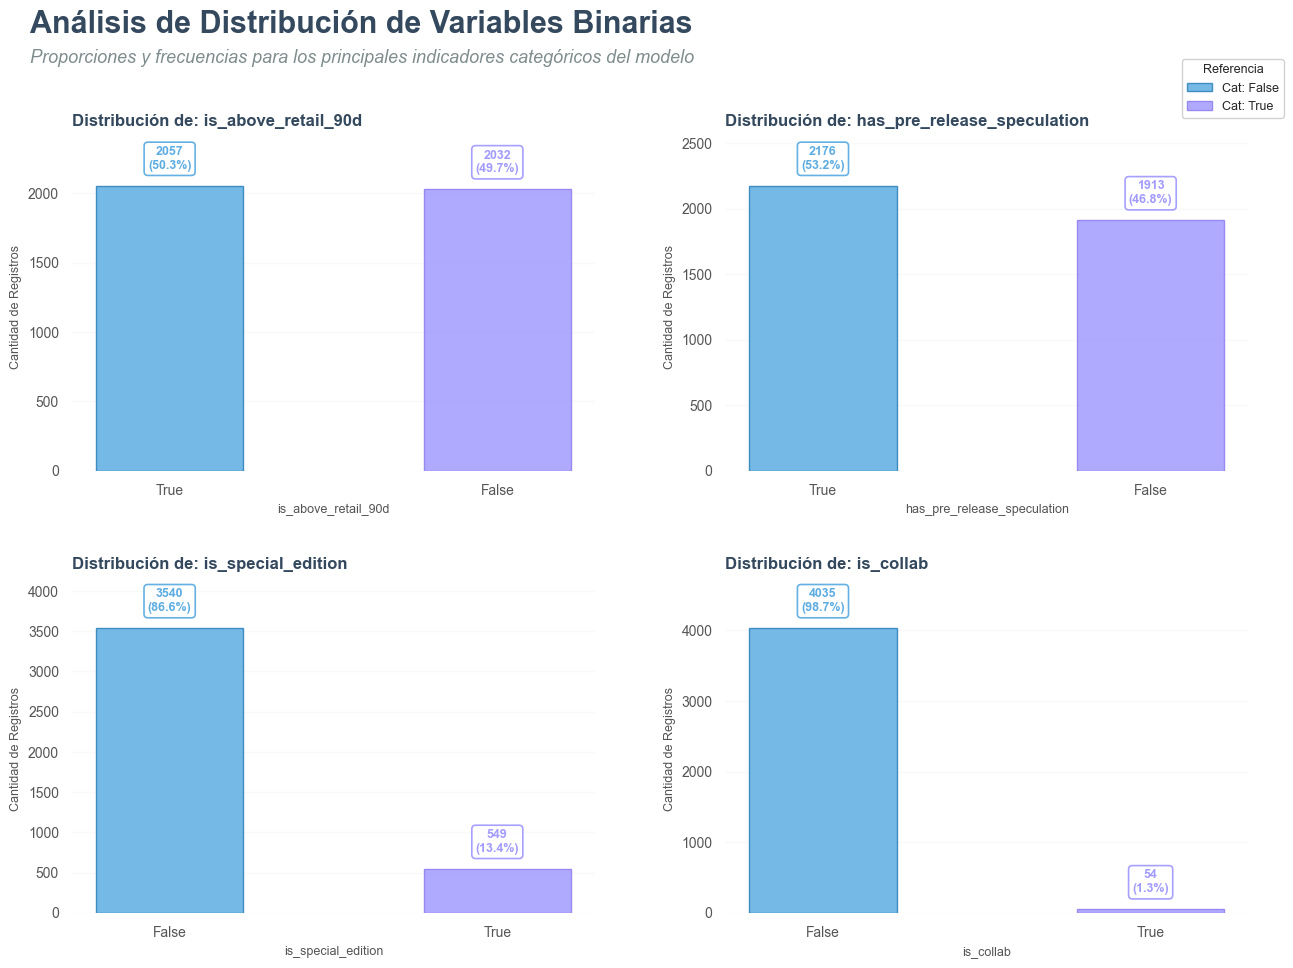

In [5]:
# --- 1. CONFIGURACIÓN GLOBAL ---
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

# Variables a graficar
variables = [
    'is_above_retail_90d',
    'has_pre_release_speculation',
    'is_special_edition',
    'is_collab'
]

# --- 2. CONFIGURACIÓN DE LA FIGURA (Matriz 2x2) ---
# Ajustamos el tamaño de la figura para albergar de forma cómoda las 4 subgráficas
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten() # Aplanamos la matriz de 2x2 a un arreglo de 4 elementos para iterar fácilmente

# TÍTULOS EDITORIALES GLOBALES
fig.text(0.05, 0.96, "Análisis de Distribución de Variables Binarias",
         fontsize=22, fontweight='bold', color='#34495e')
fig.text(0.05, 0.93,
         "Proporciones y frecuencias para los principales indicadores categóricos del modelo",
         fontsize=13, color='#7f8c8d', style='italic')

# --- 3. BUCLE PARA GENERAR CADA GRAFICO DE BARRAS ---
for i, var in enumerate(variables):
    ax = axes[i]

    # Calcular estadísticos por variable
    counts = df_modelo[var].value_counts().sort_values(ascending=False)
    proportions = df_modelo[var].value_counts(normalize=True)
    categories = counts.index.tolist()

    # Paleta y bordes dinámicos (adaptados al orden de las categorías detectadas)
    paleta = {categories[0]: '#5dade2', categories[1]: '#a29bfe'} if len(categories) >= 2 else {categories[0]: '#5dade2'}
    bordes = {categories[0]: '#2980b9', categories[1]: '#8e7cf0'} if len(categories) >= 2 else {categories[0]: '#2980b9'}

    # Rejilla sutil en el eje Y
    ax.grid(axis='y', color='#f8f9f9', linestyle='-', linewidth=1, zorder=0)

    # Generar Barplot
    bars = ax.bar(
        [str(cat) for cat in categories],
        counts.values,
        color=[paleta[cat] for cat in categories],
        edgecolor=[bordes[cat] for cat in categories],
        width=0.45,
        alpha=0.85,
        zorder=2
    )

    # Anotaciones en cada barra (Estilo caja flotante)
    for bar, cat in zip(bars, categories):
        height = bar.get_height()
        prop = proportions[cat]
        ax.annotate(
            f"{height}\n({prop:.1%})", # Salto de línea para que quepa mejor en espacios reducidos
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 10),
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=paleta[cat],
            bbox=dict(
                boxstyle='round,pad=0.3', facecolor='white',
                edgecolor=paleta[cat], linewidth=1.2, alpha=0.95
            )
        )

    # Estética interna de cada casilla (Subplot)
    ax.set_title(f"Distribución de: {var}", loc='left', fontsize=12, fontweight='bold', pad=12, color='#34495e')
    ax.set_ylabel("Cantidad de Registros", fontsize=9, color='#555555')
    ax.set_xlabel(var, fontsize=9, color='#555555')
    ax.tick_params(colors='#555555', labelsize=10)

    # Ajustar límites de Y para que la etiqueta flotante no se corte arriba
    ax.set_ylim(0, counts.max() * 1.15)

    sns.despine(ax=ax, left=True, bottom=True)

# --- 4. LEYENDA COMPARTIDA UNIFICADA ---
# Tomamos una muestra representativa de categorías comunes (ej: False/True o No/Sí) para la leyenda global
# Si tus variables tienen etiquetas idénticas (ej: todas son True/False), esto se renderizará perfectamente
sample_categories = list(paleta.keys())
legend_elements = [
    mpatches.Patch(facecolor=paleta[cat], edgecolor=bordes[cat], alpha=0.85, label=f"Cat: {cat}")
    for cat in sample_categories
]

fig.legend(
    handles=legend_elements,
    loc='upper right',
    bbox_to_anchor=(0.95, 0.94),
    fontsize=9,
    frameon=True,
    framealpha=0.9,
    edgecolor='#cccccc',
    facecolor='white',
    title='Referencia',
    title_fontsize=9,
)

# --- 5. AJUSTES FINALES GENERALES ---
# Ajustamos los espacios entre subplots para evitar superposiciones de etiquetas
plt.subplots_adjust(top=0.85, bottom=0.08, left=0.08, right=0.92, hspace=0.35, wspace=0.25)

plt.show()

## Hists

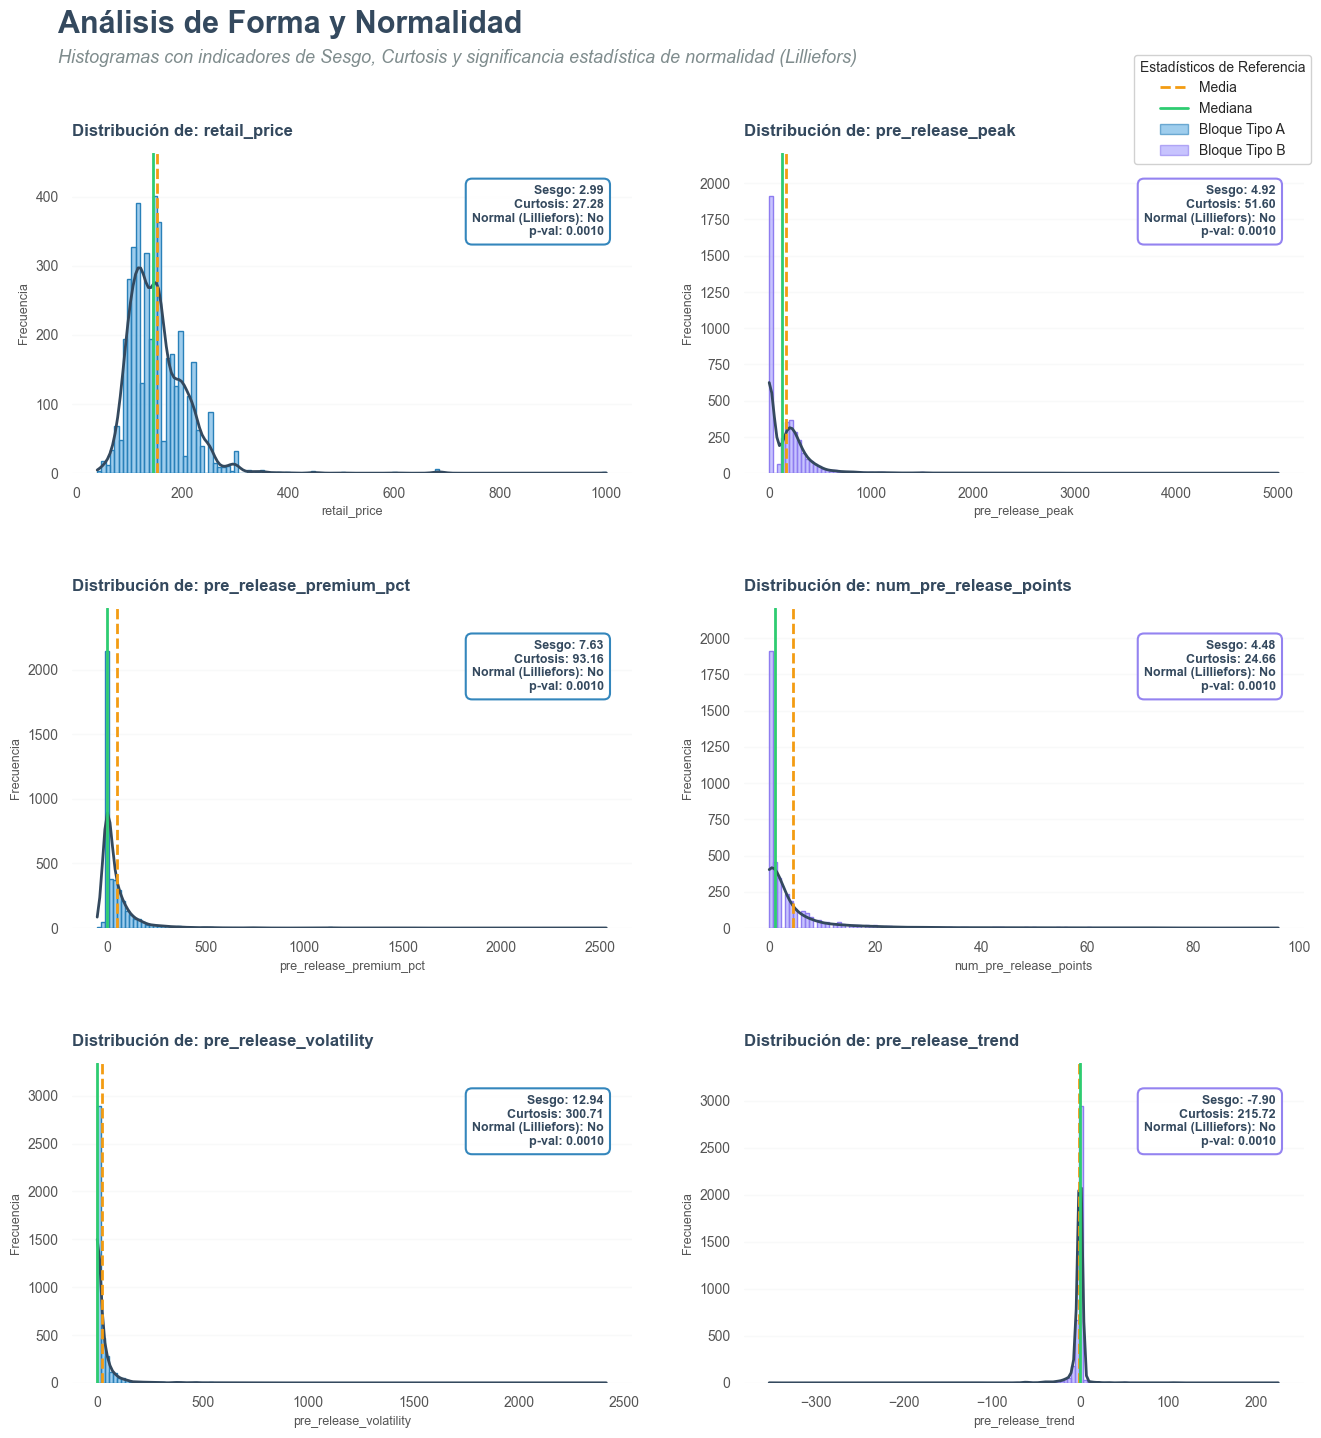

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
import numpy as np
import pandas as pd

# Importaciones para cálculos estadísticos
from scipy.stats import skew, kurtosis
from statsmodels.stats.diagnostic import lilliefors

# --- 1. CONFIGURACIÓN GLOBAL ---
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

variables = [
    'retail_price', 'pre_release_peak', 'pre_release_premium_pct',
    'num_pre_release_points', 'pre_release_volatility', 'pre_release_trend'
]

colores = ['#5dade2', '#a29bfe']
bordes  = ['#2980b9', '#8e7cf0']

# --- 2. CONFIGURACIÓN DE LA FIGURA (Matriz 3x2) ---
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 15))
axes = axes.flatten()

# TÍTULOS EDITORIALES GLOBALES
fig.text(0.05, 0.96, "Análisis de Forma y Normalidad",
         fontsize=22, fontweight='bold', color='#34495e')
fig.text(0.05, 0.94,
         "Histogramas con indicadores de Sesgo, Curtosis y significancia estadística de normalidad (Lilliefors)",
         fontsize=13, color='#7f8c8d', style='italic')

# --- 3. BUCLE PARA GENERAR CADA HISTOGRAMA ---
for i, var in enumerate(variables):
    ax = axes[i]

    # Limpieza de nulos estricta para pruebas estadísticas
    datos_var = df_modelo[var].dropna()

    # Valores de tendencia central
    media = np.mean(datos_var)
    mediana = np.median(datos_var)

    # --- CÁLCULOS ESTADÍSTICOS DE FORMA Y NORMALIDAD ---
    val_sesgo = skew(datos_var)
    val_curtosis = kurtosis(datos_var, fisher=True) # fisher=True da curtosis excedente (0 = normal)

    # Test de Lilliefors (KS modificado)
    # Retorna: (estadístico ks, p-valor)
    ks_stat, p_valor = lilliefors(datos_var, dist='norm')
    es_normal = "Sí" if p_valor > 0.05 else "No"

    # --- RENDERIZADO DEL GRÁFICO ---
    color_hist = colores[i % 2]
    color_borde = bordes[i % 2]

    ax.grid(axis='y', color='#f8f9f9', linestyle='-', linewidth=1, zorder=0)

    sns.histplot(
        datos_var,
        kde=True,
        ax=ax,
        color=color_hist,
        edgecolor=color_borde,
        linewidth=1,
        alpha=0.6,
        zorder=2
    )

    if ax.lines:
        ax.lines[0].set_color('#34495e')
        ax.lines[0].set_linewidth(2)

    # Líneas de Tendencia Central
    ax.axvline(media, color='#f39c12', linestyle='--', linewidth=2, zorder=3)
    ax.axvline(mediana, color='#2ecc71', linestyle='-', linewidth=2, zorder=3)

    # --- ANOTACIÓN DE MÉTRICAS (Estilo cuadro de texto del gráfico original) ---
    texto_metricas = (
        f"Sesgo: {val_sesgo:.2f}\n"
        f"Curtosis: {val_curtosis:.2f}\n"
        f"Normal (Lilliefors): {es_normal}\n"
        f"p-val: {p_valor:.4f}"
    )

    # Posicionamos la caja en la esquina superior derecha interna de cada subplot
    ax.text(
        0.95, 0.90, texto_metricas,
        transform=ax.transAxes, # Usa coordenadas relativas al eje (0 a 1)
        fontsize=9, fontweight='bold', color='#34495e',
        ha='right', va='top',
        bbox=dict(
            boxstyle='round,pad=0.5', facecolor='white',
            edgecolor=color_borde, linewidth=1.5, alpha=0.95
        )
    )

    # Estética interna de cada subplot
    ax.set_title(f"Distribución de: {var}", loc='left', fontsize=12, fontweight='bold', pad=12, color='#34495e')
    ax.set_ylabel("Frecuencia", fontsize=9, color='#555555')
    ax.set_xlabel(var, fontsize=9, color='#555555')
    ax.tick_params(colors='#555555', labelsize=10)

    # Añadimos un pequeño margen superior para evitar colisiones con la caja de texto
    ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

    sns.despine(ax=ax, left=True, bottom=True)

# --- 4. LEYENDA COMPARTIDA UNIFICADA ---
legend_elements = [
    Line2D([0], [0], color='#f39c12', linestyle='--', linewidth=2, label='Media'),
    Line2D([0], [0], color='#2ecc71', linestyle='-', linewidth=2, label='Mediana'),
    mpatches.Patch(facecolor=colores[0], edgecolor=bordes[0], alpha=0.6, label='Bloque Tipo A'),
    mpatches.Patch(facecolor=colores[1], edgecolor=bordes[1], alpha=0.6, label='Bloque Tipo B')
]

fig.legend(
    handles=legend_elements,
    loc='upper right',
    bbox_to_anchor=(0.95, 0.95),
    fontsize=10,
    frameon=True,
    framealpha=0.9,
    edgecolor='#cccccc',
    facecolor='white',
    title='Estadísticos de Referencia',
    title_fontsize=10,
)

# --- 5. AJUSTES FINALES GENERALES ---
plt.subplots_adjust(top=0.88, bottom=0.06, left=0.06, right=0.94, hspace=0.42, wspace=0.20)

plt.show()

Since the variables aren't normal we shouldn't use PCA/LDA

## Brand Trend

brand_historical_rate is the percentage of a brand's previous sneaker releases that successfully stayed above retail price 90 days post-launch, calculated using only past data to avoid leakage.

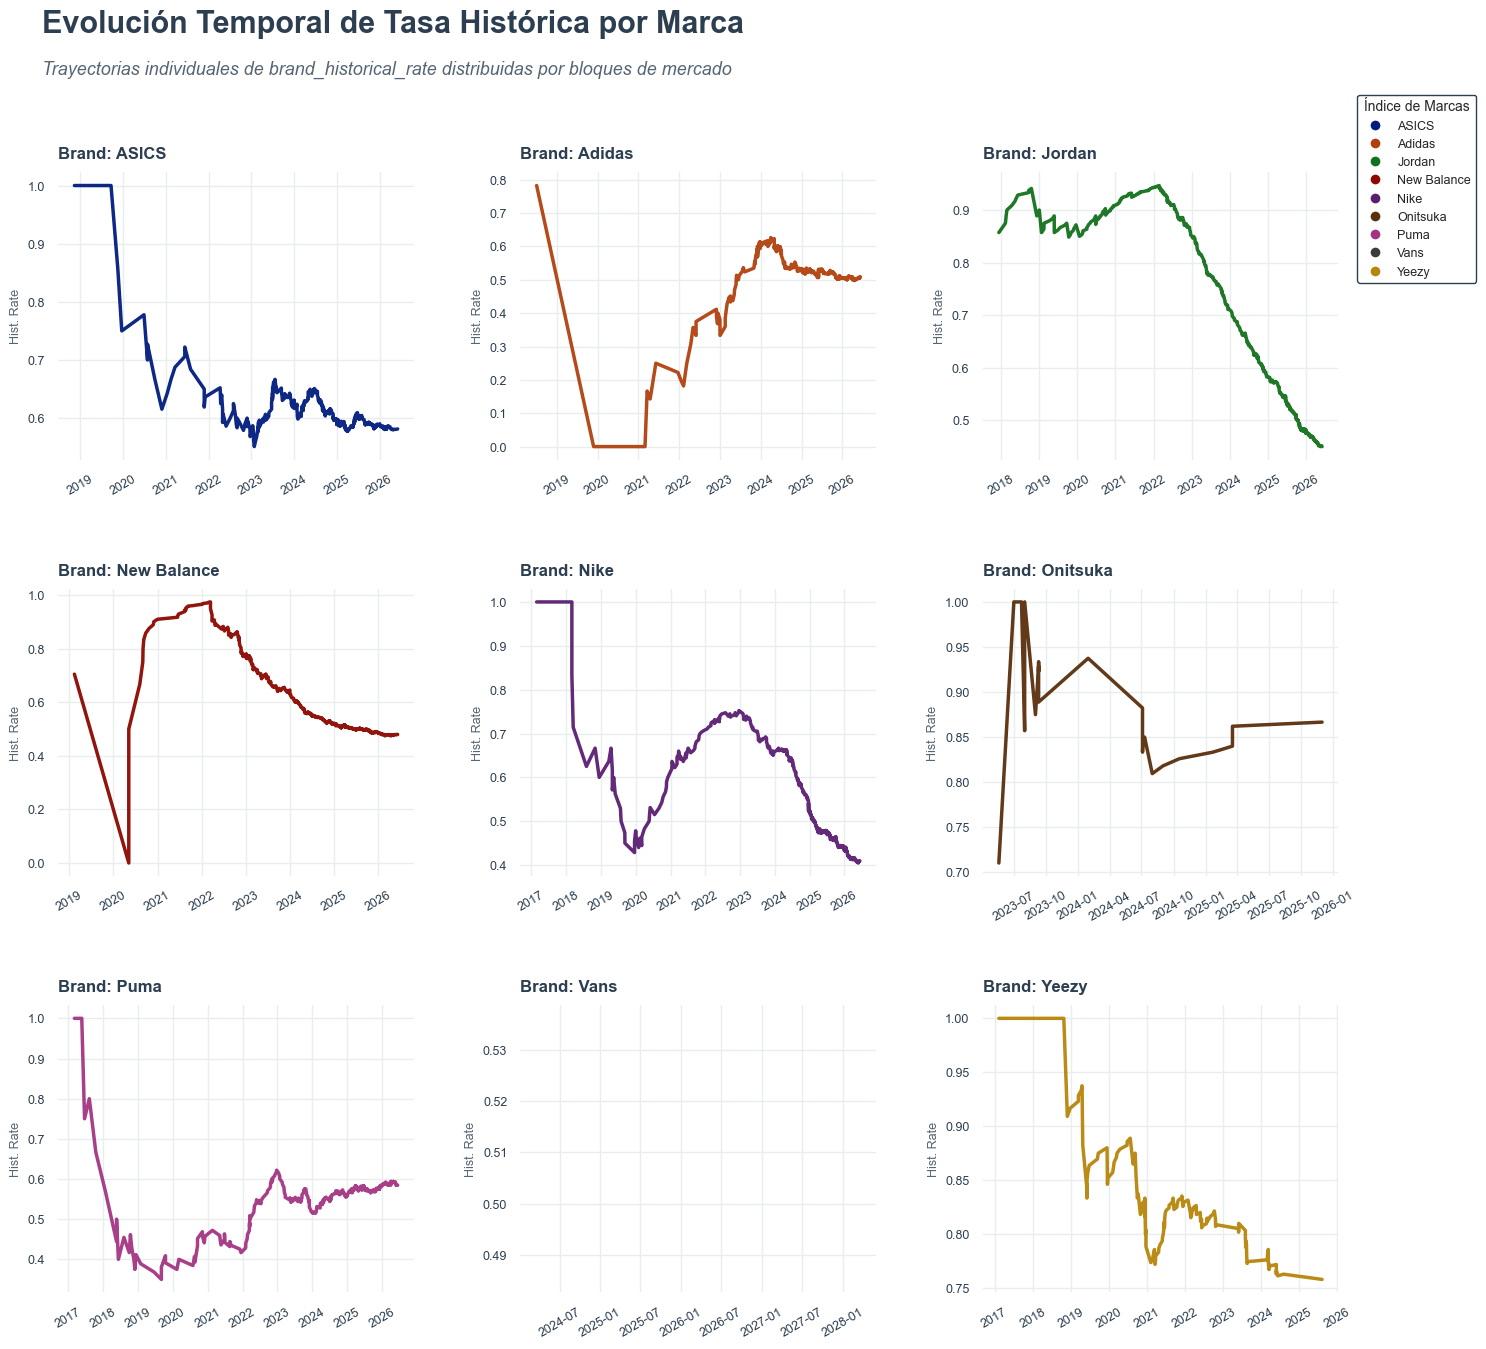

In [7]:
# --- 1. PREPROCESAMIENTO Y CONFIGURACIÓN GLOBAL ---
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

# Asegurar formato de fecha y ordenamiento cronológico por marca
df_modelo['release_date'] = pd.to_datetime(df_modelo['release_date'])
df_trend = df_modelo.dropna(subset=['release_date', 'brand_historical_rate', 'brand'])
df_trend = df_trend.sort_values(by=['brand', 'release_date'])

# Identificar las marcas únicas
brands = df_trend['brand'].unique()

# Si tienes exactamente 9 marcas, mapeamos colores de alto contraste repetibles o una lista extendida
colores_alto_contraste = ['#1b4f72', '#d35400', '#196f3d', '#7d3c98', '#2e4053',
                          # Tonos adicionales de alto contraste para completar las 9 marcas
                          # Azul eléctrico, magenta oscuro, verde oliva, rojo teja
                          # Para evitar que se parezcan entre sí
                          # O puedes usar una paleta preestablecida como 'Dark2' o 'tab10' de matplotlib
                         ]

# Usamos una paleta robusta de Seaborn con alto contraste para asegurar 9 colores bien diferenciados
colores_9 = sns.color_palette("dark", 9).as_hex()
paleta_brand = {brand: colores_9[i] for i, brand in enumerate(brands)}

# --- CONFIGURACIÓN DE MUESTREO (STRIDE) ---
# Al tener cajas individuales, puedes usar stride=1 para ver todos los puntos,
# o un número mayor si una sola marca tiene demasiada densidad.
stride = 1

# --- 2. CONFIGURACIÓN DE LA FIGURA (Matriz 3x3) ---
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 14), sharex=False, sharey=False)
axes = axes.flatten()  # Aplanamos la matriz 3x3 a una lista de 9 elementos para iterar fácilmente

# TÍTULOS EDITORIALES GLOBALES DE ALTO CONTRASTE
fig.text(0.05, 0.96, "Evolución Temporal de Tasa Histórica por Marca",
         fontsize=22, fontweight='bold', color='#2c3e50')
fig.text(0.05, 0.93,
         "Trayectorias individuales de brand_historical_rate distribuidas por bloques de mercado",
         fontsize=13, color='#566573', style='italic')

# --- 3. BUCLE DE RENDERIZADO (Una marca por casilla) ---
for i, brand in enumerate(brands):
    # Validar que no nos pasemos de los subplots disponibles si cambian las marcas
    if i >= len(axes):
        break

    ax = axes[i]
    df_b = df_trend[df_trend['brand'] == brand]

    # Rejilla bidireccional reforzada pero limpia por recuadro
    ax.grid(axis='both', color='#eaeded', linestyle='-', linewidth=1, zorder=0)

    # 3.1. Trazar la línea continua para la marca actual
    ax.plot(
        df_b['release_date'],
        df_b['brand_historical_rate'],
        color=paleta_brand[brand],
        linewidth=2.5,
        alpha=0.95,
        zorder=3
    )

    # 3.2. Aplicar el submuestreo posicional (stride) para los puntos
    # df_b_sampled = df_b.iloc[::stride]

    # # 3.3. Dibujar los marcadores sobre la línea
    # ax.scatter(
    #     df_b_sampled['release_date'],
    #     df_b_sampled['brand_historical_rate'],
    #     color=paleta_brand[brand],
    #     edgecolor='white',
    #     s=35,
    #     linewidths=1.2,
    #     zorder=4
    # )

    # --- ESTÉTICA INTERNA DE CADA SUBPLOT ---
    # Colocamos el nombre de la marca como título del recuadro
    ax.set_title(f"Brand: {brand}", loc='left', fontsize=12, fontweight='bold', pad=10, color='#2c3e50')

    # Añadimos nombres de ejes más discretos para evitar redundancia masiva en la grilla
    ax.set_ylabel("Hist. Rate", fontsize=9, color='#566573')
    ax.tick_params(colors='#2c3e50', labelsize=9, width=1.0)

    # Rotar las fechas de cada recuadro individual para que no se pisen
    ax.tick_params(axis='x', labelrotation=30)

    # Eliminar contornos exteriores rígidos (estilo minimalista plano original)
    sns.despine(ax=ax, left=True, bottom=True)

# --- 4. OCULTAR SUBPLOTS VACÍOS (Si llegasen a ser menos de 9 marcas en el df) ---
for j in range(len(brands), len(axes)):
    fig.delaxes(axes[j])

# --- 5. LEYENDA COMPARTIDA DE ALTO CONTRASTE ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=paleta_brand[brand],
           markeredgecolor='white', markersize=8, linewidth=2.5, label=brand)
    for brand in brands
]

fig.legend(
    handles=legend_elements,
    loc='upper right',
    bbox_to_anchor=(0.95, 0.92),
    fontsize=9,
    frameon=True,
    framealpha=1.0,
    edgecolor='#2c3e50',
    facecolor='white',
    title='Índice de Marcas',
    title_fontsize=10,
)

# --- 6. AJUSTES DE ESPACIADO INTERNO ---
# Se incrementa hspace y wspace para dar margen a las rotaciones de fechas y nombres de marcas sin colisiones
plt.subplots_adjust(top=0.86, bottom=0.06, left=0.06, right=0.86, hspace=0.45, wspace=0.30)

plt.show()

## Vs is_above_retail_90d

D:\Temp\ipykernel_2944\336571484.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
D:\Temp\ipykernel_2944\336571484.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
D:\Temp\ipykernel_2944\336571484.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
D:\Temp\ipykernel_2944\336571484.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
D:\Temp\ipykernel_2944\336571484.py:53: FutureWa

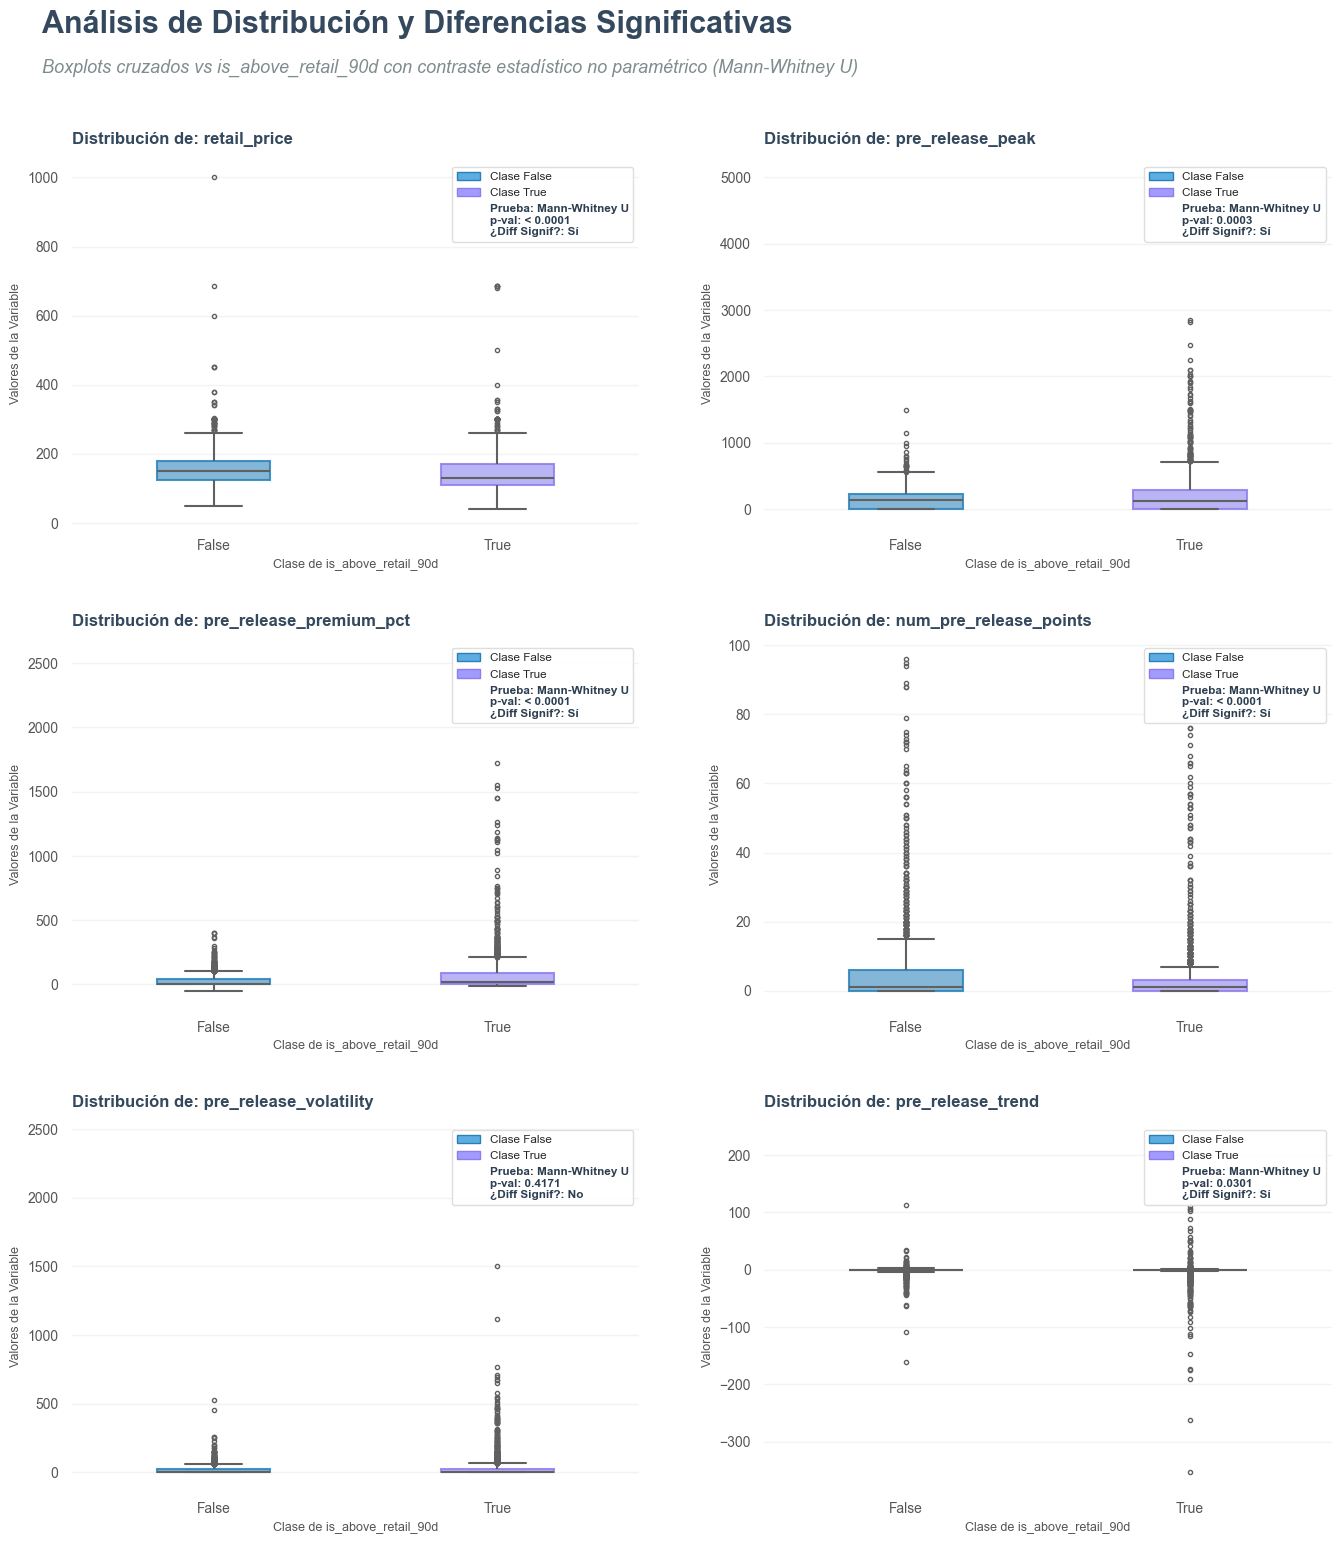

In [8]:
# --- 1. CONFIGURACIÓN GLOBAL ---
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

# Ajustamos la lista de variables numéricas y la variable objetivo de 2 clases
variables = [
    'retail_price', 'pre_release_peak', 'pre_release_premium_pct',
    'num_pre_release_points', 'pre_release_volatility', 'pre_release_trend'
]
target = 'is_above_retail_90d'

# --- 2. CONFIGURACIÓN DE LA FIGURA (Matriz 3x2 para 6 gráficos) ---
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 16))
axes = axes.flatten()  # Aplanamos para iterar fácilmente

# TÍTULOS EDITORIALES GLOBALES
fig.text(0.06, 0.96, "Análisis de Distribución y Diferencias Significativas",
         fontsize=22, fontweight='bold', color='#34495e')
fig.text(0.06, 0.935,
         f"Boxplots cruzados vs {target} con contraste estadístico no paramétrico (Mann-Whitney U)",
         fontsize=13, color='#7f8c8d', style='italic')

# --- CORRECCIÓN AQUÍ: Clases del target nativas y strings para Seaborn ---
clases_target_nativas = sorted(df_modelo[target].dropna().unique())
clases_target_str = [str(c) for c in clases_target_nativas]

# Definimos paletas usando strings para evitar el conflicto con las versiones de Seaborn
paleta = {clases_target_str[0]: '#5dade2', clases_target_str[1]: '#a29bfe'}
bordes = {clases_target_str[0]: '#2980b9', clases_target_str[1]: '#8e7cf0'}

# --- 3. BUCLE PARA GENERAR CADA BOXPLOT ---
for i, var in enumerate(variables):
    ax = axes[i]

    # Separar los datos usando las clases nativas (booleanas o numéricas)
    grupo_0 = df_modelo[df_modelo[target] == clases_target_nativas[0]][var].dropna()
    grupo_1 = df_modelo[df_modelo[target] == clases_target_nativas[1]][var].dropna()

    # Ejecutar Prueba de Mann-Whitney U
    stat, p_val = mannwhitneyu(grupo_0, grupo_1, alternative='two-sided')

    # Determinar si hay diferencia significativa (Alfa = 0.05)
    tiene_diff = p_val < 0.05
    texto_diff = "Sí" if tiene_diff else "No"

    # Formatear el p-valor para la leyenda
    p_val_fmt = f"{p_val:.4f}" if p_val >= 0.0001 else "< 0.0001"

    # Rejilla sutil de fondo en el eje Y
    ax.grid(axis='y', color='#f2f4f4', linestyle='-', linewidth=1, zorder=0)

    # Generar Boxplot con Seaborn (Pasamos los datos con x casteado a string para alinearse con la paleta)
    sns.boxplot(
        data=df_modelo.assign(**{target: df_modelo[target].astype(str)}), # Solución robusta para Seaborn
        x=target,
        y=var,
        ax=ax,
        order=clases_target_str,
        palette=paleta,
        width=0.4,
        fliersize=3,
        linewidth=1.5,
        whis=1.5,
        zorder=2
    )

    # Estilizar los bordes de las cajas
    for j, artist in enumerate(ax.artists if ax.artists else ax.patches):
        if j < len(clases_target_str):
            col_actual = bordes[clases_target_str[j]]
            artist.set_edgecolor(col_actual)
            artist.set_alpha(0.85)

    # Estética interna de cada cuadrícula
    ax.set_title(f"Distribución de: {var}", loc='left', fontsize=12, fontweight='bold', pad=12, color='#34495e')
    ax.set_ylabel("Valores de la Variable", fontsize=9, color='#555555')
    ax.set_xlabel(f"Clase de {target}", fontsize=9, color='#555555')
    ax.tick_params(colors='#555555', labelsize=10)

    # --- 4. LEYENDA INDIVIDUAL POR CUADRÍCULA ---
    patch_g0 = mpatches.Patch(facecolor=paleta[clases_target_str[0]], edgecolor=bordes[clases_target_str[0]], label=f"Clase {clases_target_str[0]}")
    patch_g1 = mpatches.Patch(facecolor=paleta[clases_target_str[1]], edgecolor=bordes[clases_target_str[1]], label=f"Clase {clases_target_str[1]}")

    info_test = mpatches.Patch(color='white', label=f"Prueba: Mann-Whitney U\np-val: {p_val_fmt}\n¿Diff Signif?: {texto_diff}")

    leg = ax.legend(
        handles=[patch_g0, patch_g1, info_test],
        loc='upper right',
        fontsize=8.5,
        frameon=True,
        framealpha=0.95,
        edgecolor='#dddddd',
        facecolor='white'
    )

    try:
        leg.get_texts()[2].set_fontweight('semibold')
        leg.get_texts()[2].set_color('#2c3e50')
    except IndexError:
        pass

    sns.despine(ax=ax, left=True, bottom=True)

# --- 5. AJUSTES FINALES GENERALES ---
plt.subplots_adjust(top=0.88, bottom=0.05, left=0.08, right=0.92, hspace=0.32, wspace=0.22)

plt.show()

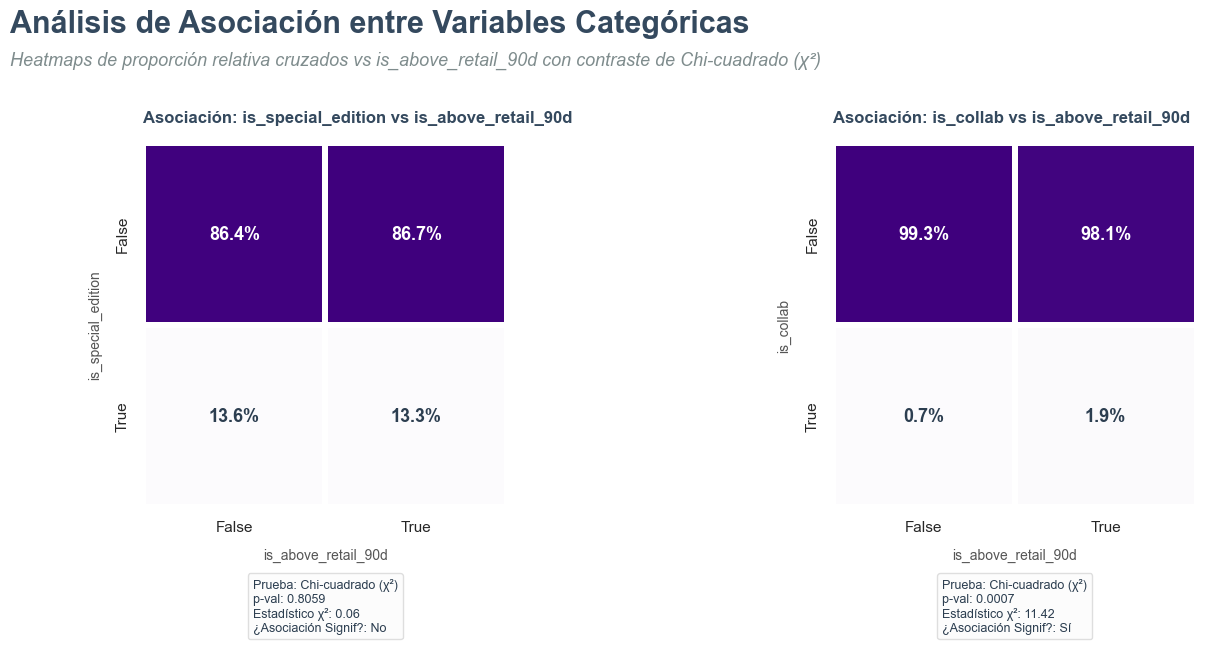

In [9]:
# --- 1. CONFIGURACIÓN GLOBAL ---
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

# Variables a cruzar contra el target
variables_binarias = ['is_special_edition', 'is_collab']
target = 'is_above_retail_90d'

# --- 2. CONFIGURACIÓN DE LA FIGURA (Matriz 1x2) ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6.5))
axes = axes.flatten()

# TÍTULOS EDITORIALES GLOBALES
fig.text(0.06, 0.95, "Análisis de Asociación entre Variables Categóricas",
         fontsize=22, fontweight='bold', color='#34495e')
fig.text(0.06, 0.90,
         f"Heatmaps de proporción relativa cruzados vs {target} con contraste de Chi-cuadrado (χ²)",
         fontsize=13, color='#7f8c8d', style='italic')

# --- 3. BUCLE PARA GENERAR CADA HEATMAP ---
for i, var in enumerate(variables_binarias):
    ax = axes[i]

    # Asegurar que no haya nulos y mapear a string para asegurar consistencia en etiquetas
    df_temp = df_modelo[[var, target]].dropna().astype(str)

    # 1. Crear Tabla de Contingencia Absoluta para el Test de Chi-cuadrado
    contingency_table = pd.crosstab(df_temp[var], df_temp[target])

    # Ejecutar Prueba de Chi-cuadrado de Independencia (con corrección de Yates por defecto para 2x2)
    chi2, p_val, dof, expected = chi2_contingency(contingency_table)

    # 2. Crear Tabla de Proporciones para el Heatmap (Normalizado por columnas/target para ver el impacto)
    # Muestra: "De los que superaron el retail (True), ¿qué % eran colaboraciones?"
    heatmap_data = pd.crosstab(df_temp[var], df_temp[target], normalize='columns') * 100

    # Determinar si hay asociación significativa (Alfa = 0.05)
    tiene_asoc = p_val < 0.05
    texto_asoc = "Sí" if tiene_asoc else "No"

    # Formatear p-valor
    p_val_fmt = f"{p_val:.4f}" if p_val >= 0.0001 else "< 0.0001"

    # Generar el Heatmap
    # Usamos una paleta secuencial sofisticada que combine con tus tonos previos (azules/purpuras)
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".1f",
        cmap="Purples",       # Paleta limpia y elegante que escala con la intensidad de la proporción
        linewidths=4,         # Separación marcada entre celdas estilo mosaico moderno
        cbar=False,           # Quitamos la barra lateral para usar la leyenda personalizada
        annot_kws={"size": 13, "weight": "bold"},
        ax=ax,
        square=True
    )

    # Configurar etiquetas de los ejes añadiendo contexto
    ax.set_title(f"Asociación: {var} vs {target}", loc='left', fontsize=12, fontweight='bold', pad=15, color='#34495e')
    ax.set_xlabel(f"{target}", fontsize=10, color='#555555', labelpad=10)
    ax.set_ylabel(f"{var}", fontsize=10, color='#555555', labelpad=10)

    # Añadir el sufijo '%' a las anotaciones del mapa de calor internamente
    for text in ax.texts:
        text.set_text(text.get_text() + "%")
        text.set_color("#2c3e50" if float(text.get_text().replace('%','')) < 50 else "white")

    # --- 4. LEYENDA ESTADÍSTICA INDIVIDUAL POR CUADRÍCULA ---
    # Parche invisible/blanco para estructurar la info en formato caja editorial
    info_test = mpatches.Patch(
        color='white',
        label=f"Prueba: Chi-cuadrado (χ²)\n"
              f"p-val: {p_val_fmt}\n"
              f"Estadístico χ²: {chi2:.2f}\n"
              f"¿Asociación Signif?: {texto_asoc}"
    )

    leg = ax.legend(
        handles=[info_test],
        loc='lower center',
        bbox_to_anchor=(0.5, -0.38),  # Posicionado abajo de forma simétrica
        fontsize=9,
        frameon=True,
        framealpha=0.95,
        edgecolor='#dddddd',
        facecolor='#fcfcfc',
        handlelength=0,                # Oculta el cuadro de color del parche para que parezca solo texto
        handletextpad=0
    )

    # Estilizar la última línea de la leyenda (¿Asociación Signif?)
    try:
        leg.get_texts()[0].set_fontweight('medium')
        leg.get_texts()[0].set_color('#2c3e50')
    except IndexError:
        pass

# --- 5. AJUSTES FINALES GENERALES ---
# Ampliamos el margen inferior (`bottom`) para que las leyendas de las pruebas no se corten
plt.subplots_adjust(top=0.78, bottom=0.22, left=0.10, right=0.90, wspace=0.35)

plt.show()

# Data Prep

## Search for outliers

In [10]:
df_numerico = df_modelo.select_dtypes(include=['number'])


Q1 = df_numerico.quantile(0.25)
Q3 = df_numerico.quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


atipicos = (df_numerico < limite_inferior) | (df_numerico > limite_superior)

tabla_atipicos = pd.DataFrame({
    'Cantidad Atípicos': atipicos.sum(),
    'Proporción Atípicos (%)': (atipicos.mean() * 100).round(2)
})

tabla_atipicos = tabla_atipicos.sort_values(by='Proporción Atípicos (%)', ascending=False)

tabla_atipicos

,Cantidad Atípicos,Proporción Atípicos (%)
pre_release_trend,758,18.54
num_pre_release_points,453,11.08
pre_release_volatility,410,10.03
brand_historical_rate,398,9.73
pre_release_premium_pct,347,8.49
days_speculation_window,325,7.95
pre_release_peak,139,3.40
release_year,114,2.79
retail_price,80,1.96
title_length,80,1.96


we should use RobustScaler

## Multicollinearity

In [11]:
columnas_numericas = [
    'pre_release_trend', 'num_pre_release_points', 'pre_release_volatility',
    'brand_historical_rate', 'pre_release_premium_pct', 'days_speculation_window',
    'pre_release_peak', 'retail_price', 'title_length'
]

X = df_modelo[columnas_numericas].dropna()
X_con_constante = add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_con_constante.columns
vif_data["VIF"] = [variance_inflation_factor(X_con_constante.values, i) for i in range(len(X_con_constante.columns))]

vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("--- VIF ---")
vif_data

--- VIF ---


,Variable,VIF
0,const,45.638645
1,pre_release_peak,7.683141
2,pre_release_premium_pct,5.850787
3,pre_release_volatility,4.098219
4,num_pre_release_points,1.751461
5,days_speculation_window,1.468211
6,retail_price,1.391589
7,pre_release_trend,1.358932
8,brand_historical_rate,1.194602
9,title_length,1.046800


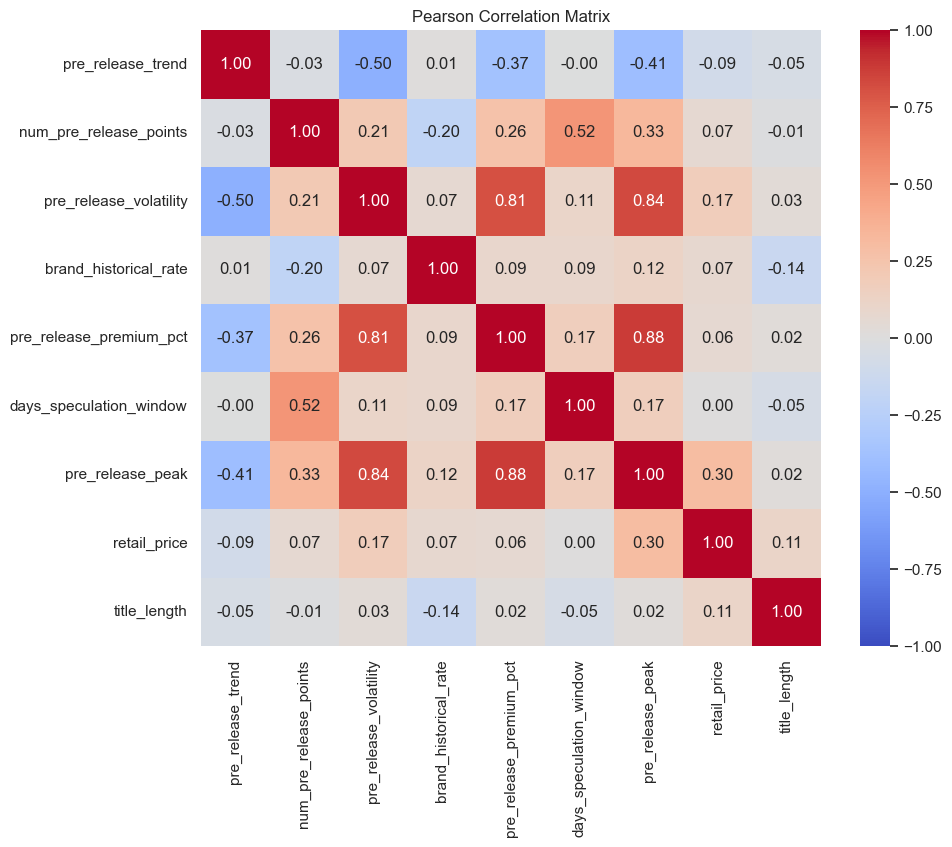

In [12]:
plt.figure(figsize=(10, 8))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pearson Correlation Matrix")
plt.show()

### df created to be used with linear models

In [13]:
df_lin_model = df_modelo.drop(columns=['pre_release_peak']).copy()

In [14]:
columnas_numericas = [
    'pre_release_trend', 'num_pre_release_points', 'pre_release_volatility',
    'brand_historical_rate', 'pre_release_premium_pct', 'days_speculation_window',
    'retail_price', 'title_length'
]

X = df_lin_model[columnas_numericas].dropna()
X_con_constante = add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_con_constante.columns
vif_data["VIF"] = [variance_inflation_factor(X_con_constante.values, i) for i in range(len(X_con_constante.columns))]

vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
print("--- VIF  ---")
vif_data

--- VIF  ---


,Variable,VIF
0,const,43.958897
1,pre_release_volatility,3.518813
2,pre_release_premium_pct,3.112378
3,num_pre_release_points,1.618053
4,days_speculation_window,1.457227
5,pre_release_trend,1.352170
6,brand_historical_rate,1.166869
7,retail_price,1.080797
8,title_length,1.043648


In [15]:
df_lin_model.columns

Index(['title', 'retail_price', 'release_date', 'brand',
       'pre_release_premium_pct', 'is_above_retail_90d',
       'has_pre_release_speculation', 'num_pre_release_points',
       'pre_release_volatility', 'pre_release_trend',
       'days_speculation_window', 'release_year', 'release_month',
       'release_quarter', 'release_dow', 'brand_historical_rate',
       'title_length', 'is_collab', 'is_special_edition', 'brand_grouped'],
      dtype='object')

# Scalers

In [16]:
df_modelo = df_modelo.sort_values('release_date').reset_index(drop=True)

## Temporal split

In [17]:
df_modelo = df_modelo.sort_values('release_date').reset_index(drop=True)
df_lin_model = df_lin_model.sort_values('release_date').reset_index(drop=True)

TEST_SIZE = 0.2  # último 20% cronológico como test

split_idx_modelo = int(len(df_modelo) * (1 - TEST_SIZE))
split_date_modelo = df_modelo.iloc[split_idx_modelo]['release_date']

split_idx_lin = int(len(df_lin_model) * (1 - TEST_SIZE))
split_date_lin = df_lin_model.iloc[split_idx_lin]['release_date']

train_modelo = df_modelo[df_modelo['release_date'] < split_date_modelo].copy()
test_modelo  = df_modelo[df_modelo['release_date'] >= split_date_modelo].copy()

train_lin = df_lin_model[df_lin_model['release_date'] < split_date_lin].copy()
test_lin  = df_lin_model[df_lin_model['release_date'] >= split_date_lin].copy()

print(f"df_modelo    -> train: {len(train_modelo)} | test: {len(test_modelo)} | corte: {split_date_modelo.date()}")
print(f"df_lin_model -> train: {len(train_lin)} | test: {len(test_lin)} | corte: {split_date_lin.date()}")


df_modelo    -> train: 3271 | test: 818 | corte: 2025-12-03
df_lin_model -> train: 3271 | test: 818 | corte: 2025-12-03


D:\Temp\ipykernel_2944\1458315522.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
D:\Temp\ipykernel_2944\1458315522.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
D:\Temp\ipykernel_2944\1458315522.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
D:\Temp\ipykernel_2944\1458315522.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


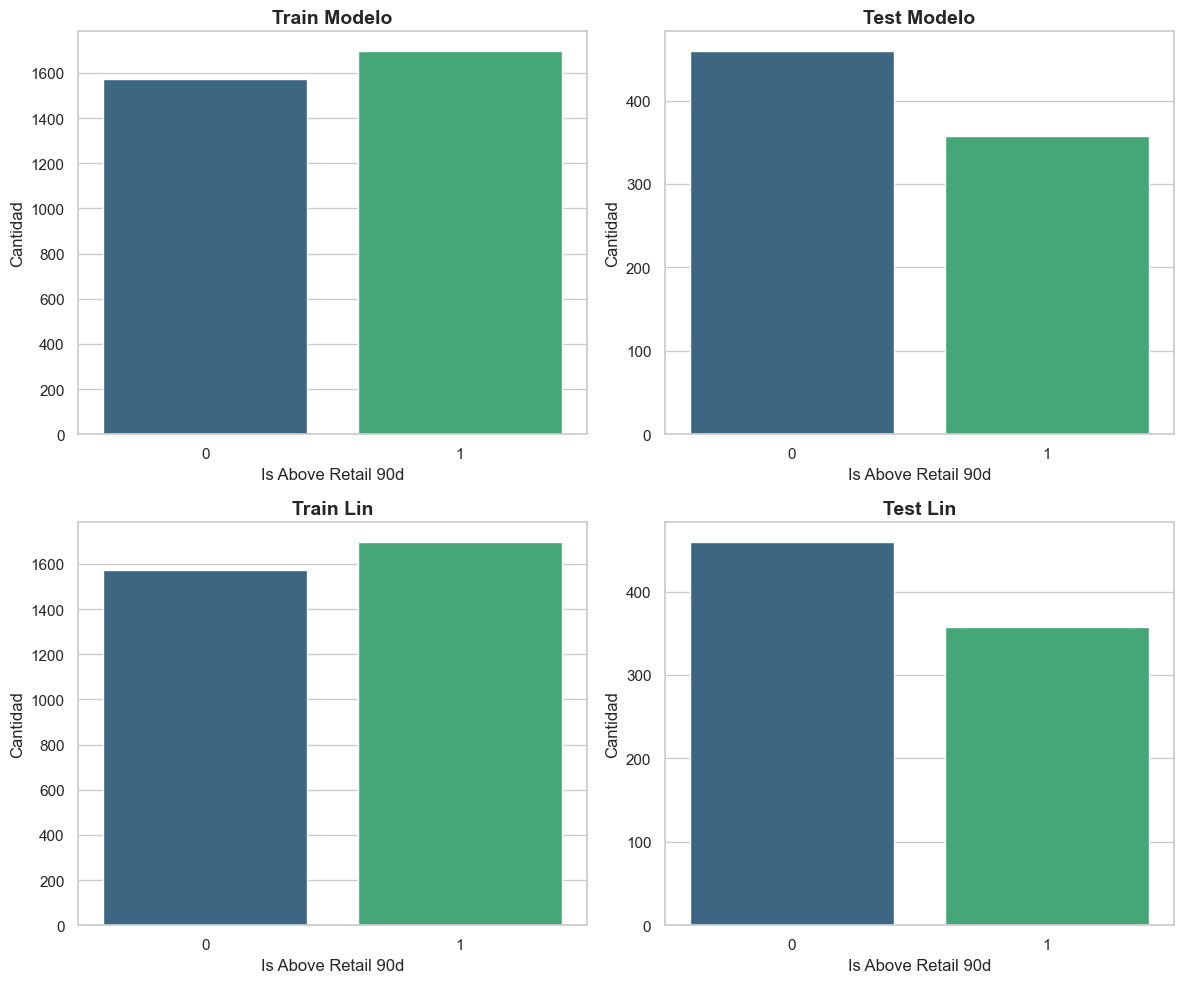

In [88]:
# Configurar el estilo visual de seaborn
sns.set_theme(style="whitegrid")

# Crear una figura con 4 subgráficos (cuadros independientes) en una cuadrícula de 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Lista de tus DataFrames y sus respectivos títulos para iterar fácilmente
dfs = [train_modelo, test_modelo, train_lin, test_lin]
titulos = ["Train Modelo", "Test Modelo", "Train Lin", "Test Lin"]

# Aplanar la matriz de ejes (axes) para iterar en una sola dimensión
axes = axes.flatten()

# Generar cada gráfico de barras
for i, df in enumerate(dfs):
    # sns.countplot es ideal para graficar la frecuencia de variables categóricas/binarias
    sns.countplot(
        data=df, x="is_above_retail_90d", ax=axes[i], palette="viridis"
    )
    axes[i].set_title(titulos[i], fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Is Above Retail 90d", fontsize=12)
    axes[i].set_ylabel("Cantidad", fontsize=12)

# Ajustar el diseño para que no se encimen los títulos y etiquetas
plt.tight_layout()

# Mostrar el gráfico
plt.show()

## Choose cols

In [18]:
cols_referencia = ['title', 'release_date', 'brand', 'brand_grouped']
cols_target = ['is_above_retail_90d']
cols_categoricas_pendientes = ['release_month', 'release_quarter', 'release_dow', 'release_year']
cols_booleanas = ['has_pre_release_speculation', 'is_collab', 'is_special_edition']

cols_excluir = cols_referencia + cols_target + cols_categoricas_pendientes + cols_booleanas

def columnas_a_escalar(df):
    candidatas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns
    return [c for c in candidatas if c not in cols_excluir]

cols_scale_modelo = columnas_a_escalar(train_modelo)
cols_scale_lin = columnas_a_escalar(train_lin)

print("\nColumnas a escalar en df_modelo:", cols_scale_modelo)
print("Columnas a escalar en df_lin_model:", cols_scale_lin)


Columnas a escalar en df_modelo: ['retail_price', 'pre_release_peak', 'pre_release_premium_pct', 'num_pre_release_points', 'pre_release_volatility', 'pre_release_trend', 'days_speculation_window', 'brand_historical_rate', 'title_length']
Columnas a escalar en df_lin_model: ['retail_price', 'pre_release_premium_pct', 'num_pre_release_points', 'pre_release_volatility', 'pre_release_trend', 'days_speculation_window', 'brand_historical_rate', 'title_length']


## Scaling

In [19]:
scaler_modelo = RobustScaler()
train_modelo[cols_scale_modelo] = scaler_modelo.fit_transform(train_modelo[cols_scale_modelo])
test_modelo[cols_scale_modelo]  = scaler_modelo.transform(test_modelo[cols_scale_modelo])

scaler_lin = RobustScaler()
train_lin[cols_scale_lin] = scaler_lin.fit_transform(train_lin[cols_scale_lin])
test_lin[cols_scale_lin]  = scaler_lin.transform(test_lin[cols_scale_lin])

In [20]:
print(train_lin['brand_historical_rate'].unique()[:10])

[ 2.76899232  1.11463674  1.44550785  0.56318488  1.82364627 -0.06704582
  1.94181453  2.03372317  2.10725009  1.6660886 ]


# Categorical coding 

## For trees

In [21]:
SMOOTHING = 10

def fit_target_encoding(train_df, cat_col, target_col, smoothing=SMOOTHING):
    global_mean = train_df[target_col].mean()
    stats = train_df.groupby(cat_col)[target_col].agg(['mean', 'count'])
    stats['smoothed_mean'] = (
        (stats['count'] * stats['mean'] + smoothing * global_mean) /
        (stats['count'] + smoothing)
    )
    return stats['smoothed_mean'].to_dict(), global_mean

def apply_target_encoding(df, cat_col, mapping, global_mean, new_col):
    df[new_col] = df[cat_col].map(mapping).fillna(global_mean)
    return df

brand_mapping, brand_global_mean = fit_target_encoding(
    train_modelo, 'brand_grouped', 'is_above_retail_90d'
)

train_modelo = apply_target_encoding(train_modelo, 'brand_grouped', brand_mapping, brand_global_mean, 'brand_grouped_encoded')
test_modelo  = apply_target_encoding(test_modelo,  'brand_grouped', brand_mapping, brand_global_mean, 'brand_grouped_encoded')

# brand_grouped categórica ya no se necesita para modelar (queda brand_grouped_encoded)
train_modelo = train_modelo.drop(columns=['brand_grouped'])
test_modelo  = test_modelo.drop(columns=['brand_grouped'])

## For linear

In [22]:
train_lin = pd.get_dummies(train_lin, columns=['brand_grouped'], prefix='brand', drop_first=True)
test_lin  = pd.get_dummies(test_lin,  columns=['brand_grouped'], prefix='brand', drop_first=True)

train_lin, test_lin = train_lin.align(test_lin, join='left', axis=1, fill_value=0)

dummy_cols = [c for c in train_lin.columns if c.startswith('brand_') and c != 'brand_historical_rate']
train_lin[dummy_cols] = train_lin[dummy_cols].astype(int)
test_lin[dummy_cols]  = test_lin[dummy_cols].astype(int)

# ------- dates ---------
def add_cyclical_features(df, col, period):
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / period)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / period)
    return df

for d in [train_lin, test_lin]:
    add_cyclical_features(d, 'release_month', 12)
    add_cyclical_features(d, 'release_quarter', 4)
    add_cyclical_features(d, 'release_dow', 7)

train_lin = train_lin.drop(columns=['release_month', 'release_quarter', 'release_dow'])
test_lin  = test_lin.drop(columns=['release_month', 'release_quarter', 'release_dow'])

print("df_modelo (train) columnas finales:", train_modelo.columns.tolist())
print("\ndf_lin_model (train) columnas finales:", train_lin.columns.tolist())
print("\nbrand_grouped_encoded (train) preview:")
print(train_modelo[['brand_grouped_encoded', 'is_above_retail_90d']].head())

df_modelo (train) columnas finales: ['title', 'retail_price', 'release_date', 'brand', 'pre_release_peak', 'pre_release_premium_pct', 'is_above_retail_90d', 'has_pre_release_speculation', 'num_pre_release_points', 'pre_release_volatility', 'pre_release_trend', 'days_speculation_window', 'release_year', 'release_month', 'release_quarter', 'release_dow', 'brand_historical_rate', 'title_length', 'is_collab', 'is_special_edition', 'brand_grouped_encoded']

df_lin_model (train) columnas finales: ['title', 'retail_price', 'release_date', 'brand', 'pre_release_premium_pct', 'is_above_retail_90d', 'has_pre_release_speculation', 'num_pre_release_points', 'pre_release_volatility', 'pre_release_trend', 'days_speculation_window', 'release_year', 'brand_historical_rate', 'title_length', 'is_collab', 'is_special_edition', 'brand_Adidas', 'brand_Jordan', 'brand_New Balance', 'brand_Nike', 'brand_Onitsuka', 'brand_Puma', 'brand_Yeezy', 'release_month_sin', 'release_month_cos', 'release_quarter_sin', '

## Using Correct data types

In [23]:
train_modelo.isna().sum()

title                          0
retail_price                   0
release_date                   0
brand                          0
pre_release_peak               0
pre_release_premium_pct        0
is_above_retail_90d            0
has_pre_release_speculation    0
num_pre_release_points         0
pre_release_volatility         0
pre_release_trend              0
days_speculation_window        0
release_year                   0
release_month                  0
release_quarter                0
release_dow                    0
brand_historical_rate          0
title_length                   0
is_collab                      0
is_special_edition             0
brand_grouped_encoded          0
dtype: int64

In [24]:
for d in [train_modelo, test_modelo, train_lin, test_lin]:
    d['is_above_retail_90d'] = d['is_above_retail_90d'].astype(int)

In [25]:
train_modelo['is_above_retail_90d']

0       1
1       1
2       1
3       1
4       1
       ..
3266    1
3267    0
3268    1
3269    0
3270    0
Name: is_above_retail_90d, Length: 3271, dtype: int64

In [26]:
print(train_lin['brand_historical_rate'].unique()[:10])

[ 2.76899232  1.11463674  1.44550785  0.56318488  1.82364627 -0.06704582
  1.94181453  2.03372317  2.10725009  1.6660886 ]


In [27]:
print(train_modelo['brand_historical_rate'].unique()[:10])

[ 2.76899232  1.11463674  1.44550785  0.56318488  1.82364627 -0.06704582
  1.94181453  2.03372317  2.10725009  1.6660886 ]


## Final Prep

In [28]:
cols_no_feature = ['title', 'release_date', 'brand', 'release_year']

# Guardamos referencia ANTES de eliminar (mismo índice que cada df,
# útil luego para diagnosticar errores del modelo por año/marca/título)
ref_train_modelo = train_modelo[cols_no_feature].copy()
ref_test_modelo  = test_modelo[cols_no_feature].copy()
ref_train_lin    = train_lin[cols_no_feature].copy()
ref_test_lin     = test_lin[cols_no_feature].copy()

for d in [train_modelo, test_modelo, train_lin, test_lin]:
    d.drop(columns=cols_no_feature, inplace=True, errors='ignore')

print("train_modelo:", train_modelo.shape, "->", train_modelo.columns.tolist())
print("\ntrain_lin:", train_lin.shape, "->", train_lin.columns.tolist())
print("\ndtypes train_modelo:\n", train_modelo.dtypes.value_counts())
print("\ndtypes train_lin:\n", train_lin.dtypes.value_counts())

train_modelo: (3271, 17) -> ['retail_price', 'pre_release_peak', 'pre_release_premium_pct', 'is_above_retail_90d', 'has_pre_release_speculation', 'num_pre_release_points', 'pre_release_volatility', 'pre_release_trend', 'days_speculation_window', 'release_month', 'release_quarter', 'release_dow', 'brand_historical_rate', 'title_length', 'is_collab', 'is_special_edition', 'brand_grouped_encoded']

train_lin: (3271, 25) -> ['retail_price', 'pre_release_premium_pct', 'is_above_retail_90d', 'has_pre_release_speculation', 'num_pre_release_points', 'pre_release_volatility', 'pre_release_trend', 'days_speculation_window', 'brand_historical_rate', 'title_length', 'is_collab', 'is_special_edition', 'brand_Adidas', 'brand_Jordan', 'brand_New Balance', 'brand_Nike', 'brand_Onitsuka', 'brand_Puma', 'brand_Yeezy', 'release_month_sin', 'release_month_cos', 'release_quarter_sin', 'release_quarter_cos', 'release_dow_sin', 'release_dow_cos']

dtypes train_modelo:
 float64    10
bool        3
int32      

# Feature Selection

## Filter Method

In [29]:
TARGET = 'is_above_retail_90d'

def calcular_score_relevancia(df, target_col):
    vars_pred = df.columns.difference([target_col]).tolist()
    X = df[vars_pred].values
    y = df[target_col].values

    # Tratamos como "discretas" las columnas binarias (0/1) -- booleanas
    # casteadas e is_collab, is_special_edition, brand_* dummies --
    # y como continuas el resto (precios, tasas, sin/cos, etc.).
    # mutual_info_classif estima mejor la MI cuando se le indica esto.
    discrete_mask = [df[col].dropna().isin([0, 1]).all() for col in vars_pred]

    mi_scores = mutual_info_classif(
        X, y, discrete_features=discrete_mask, random_state=42
    )
    df_mi = pd.DataFrame({'variable': vars_pred, 'info_mutua': mi_scores}).set_index('variable')

    corr = df.corr()[target_col].drop(target_col).reindex(vars_pred)

    scaler = MinMaxScaler()
    corr_scaled = scaler.fit_transform(corr.abs().values.reshape(-1, 1)).flatten()
    mi_scaled = scaler.fit_transform(df_mi.reindex(vars_pred)['info_mutua'].values.reshape(-1, 1)).flatten()

    df_score = pd.DataFrame({
        'variable': vars_pred,
        'corr_scaled': corr_scaled,
        'mi_scaled': mi_scaled,
    })
    df_score['score'] = (df_score['corr_scaled'] + df_score['mi_scaled']) / 2
    df_score = df_score.sort_values('score', ascending=True).set_index('variable')
    return df_score

In [30]:
df_score_lin = calcular_score_relevancia(train_lin, TARGET)
df_score_modelo = calcular_score_relevancia(train_modelo, TARGET)

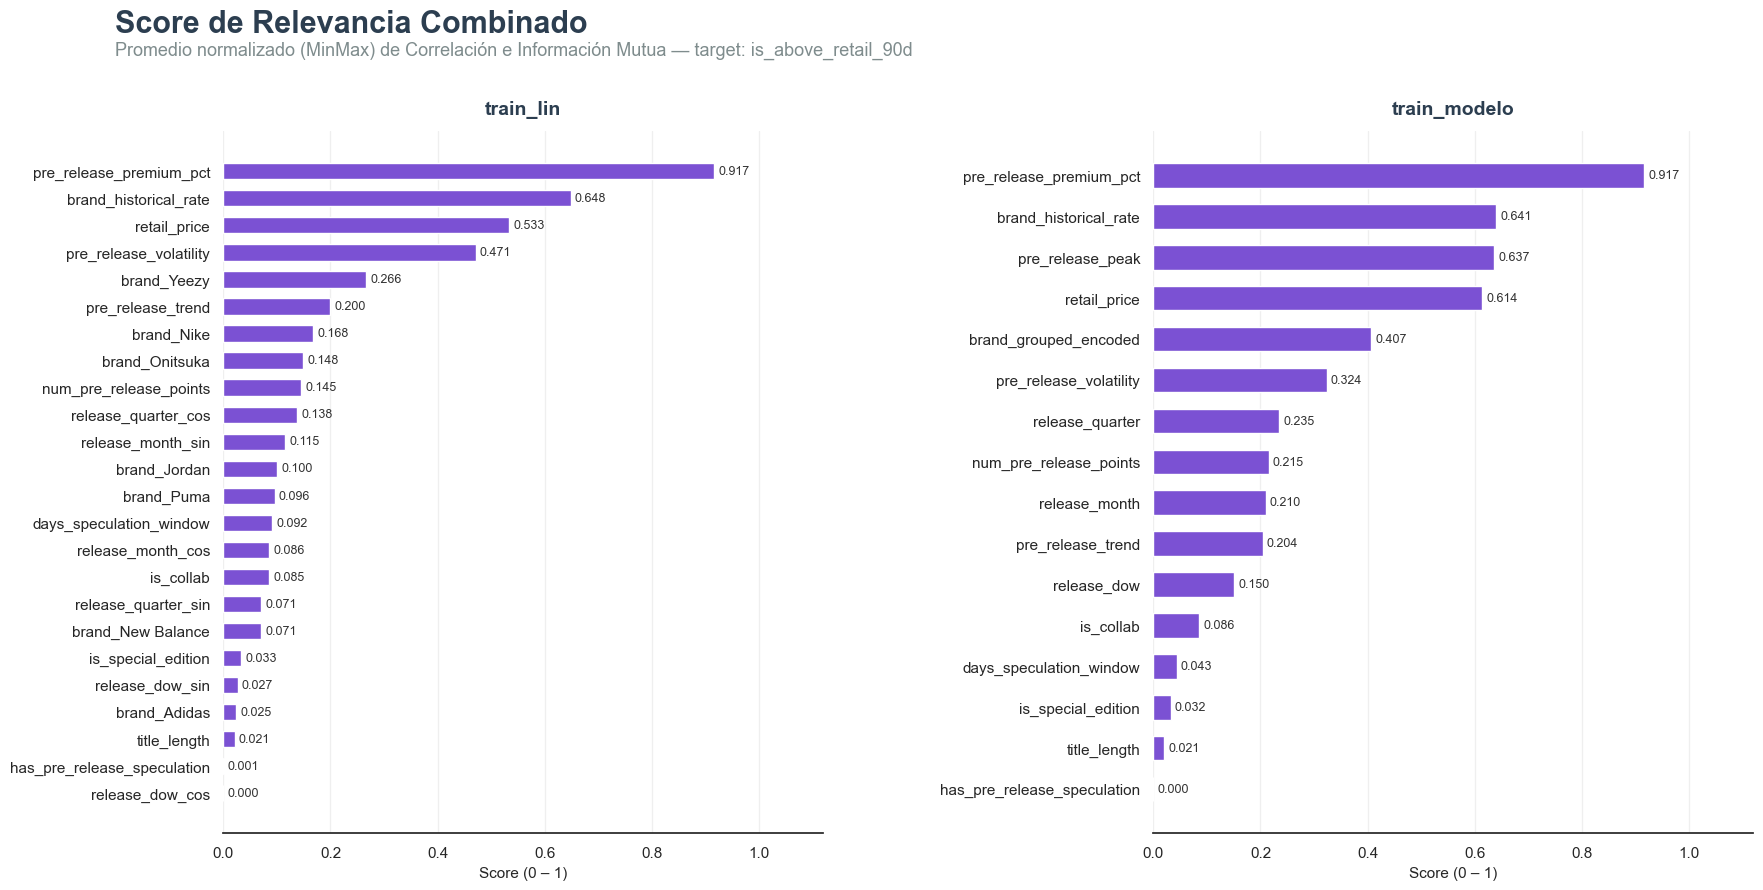

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

fig.text(0.06, 0.97, "Score de Relevancia Combinado", fontsize=22,
          fontweight='bold', color='#2c3e50')
fig.text(0.06, 0.945, "Promedio normalizado (MinMax) de Correlación e Información Mutua — target: is_above_retail_90d",
          fontsize=13, color='#7f8c8d')

datasets = [
    (df_score_lin, 'train_lin', axes[0]),
    (df_score_modelo, 'train_modelo', axes[1]),
]

for df_score, nombre, ax in datasets:
    bars = ax.barh(df_score.index, df_score['score'],
                    color='#7b51d3', edgecolor='white', height=0.6)

    for bar, val in zip(bars, df_score['score']):
        ax.text(val + 0.008, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', ha='left', fontsize=9, color='#333333')

    ax.set_title(nombre, fontsize=14, fontweight='bold', color='#2c3e50', pad=12)
    ax.set_xlabel('Score (0 – 1)', fontsize=11)
    ax.set_xlim(0, 1.12)
    ax.grid(axis='x', alpha=0.3)
    sns.despine(left=True, ax=ax)

plt.subplots_adjust(top=0.86, left=0.12, right=0.97, bottom=0.08, wspace=0.55)
plt.show()

In [32]:
def get_pre_release_premium_pct(pre_release_peak, retail_price):

    pre_release_premium_pct = (
        (pre_release_peak - retail_price) / retail_price * 100 if retail_price else 0
    )

    return pre_release_premium_pct

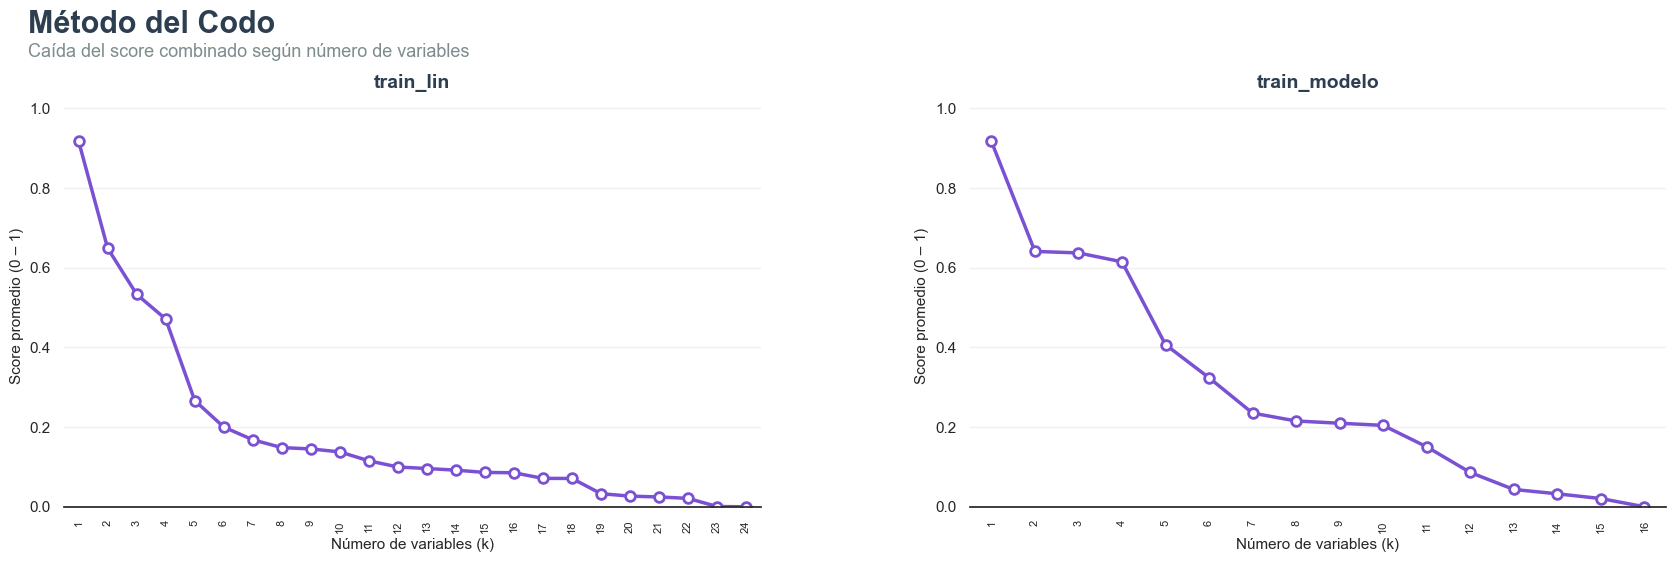

In [33]:
scores_lin_ordenados = df_score_lin['score'].sort_values(ascending=False).values
scores_modelo_ordenados = df_score_modelo['score'].sort_values(ascending=False).values

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

fig.text(0.06, 0.97, "Método del Codo", fontsize=22,
          fontweight='bold', color='#2c3e50')
fig.text(0.06, 0.93, "Caída del score combinado según número de variables",
          fontsize=13, color='#7f8c8d')

datasets = [
    (scores_lin_ordenados, 'train_lin', axes[0]),
    (scores_modelo_ordenados, 'train_modelo', axes[1]),
]

for scores_ordenados, nombre, ax in datasets:
    ax.plot(range(1, len(scores_ordenados) + 1), scores_ordenados,
            color='#7b51d3', linewidth=2.5, marker='o',
            markersize=7, markerfacecolor='white',
            markeredgecolor='#7b51d3', markeredgewidth=2)

    ax.set_title(nombre, fontsize=14, fontweight='bold', color='#2c3e50', pad=12)
    ax.set_xlabel('Número de variables (k)', fontsize=11)
    ax.set_ylabel('Score promedio (0 – 1)', fontsize=11)
    ax.set_xticks(range(1, len(scores_ordenados) + 1))
    ax.set_xticklabels(range(1, len(scores_ordenados) + 1), fontsize=8, rotation=90)
    ax.set_xlim(0.5, len(scores_ordenados) + 0.5)
    ax.set_ylim(0, max(scores_lin_ordenados.max(), scores_modelo_ordenados.max()) * 1.1)
    ax.grid(axis='y', alpha=0.3)
    sns.despine(left=True, ax=ax)

plt.subplots_adjust(top=0.85, left=0.08, right=0.97, bottom=0.18, wspace=0.3)
plt.show()

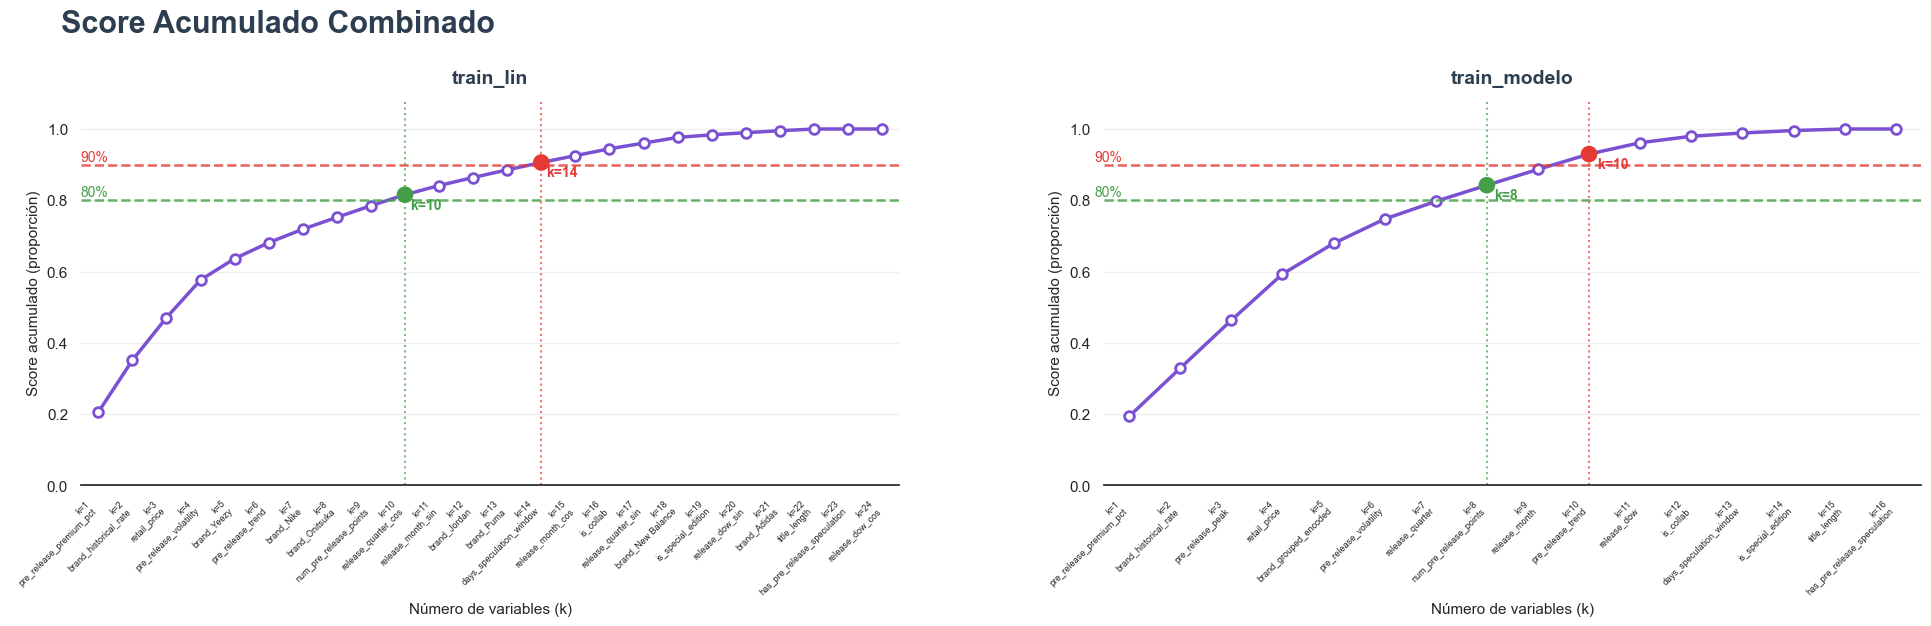

train_lin     -> k_80=10, k_90=14 (de 24 variables)
train_modelo  -> k_80=8, k_90=10 (de 16 variables)


In [34]:
# ============================================================
# SCORE ACUMULADO — 2 recuadros (train_lin | train_modelo)
# ============================================================
def calcular_acumulado(df_score):
    scores_ord = df_score['score'].sort_values(ascending=False)
    scores_norm = scores_ord / scores_ord.sum()
    scores_acum = scores_norm.cumsum()

    umbral_80 = (scores_acum >= 0.80).idxmax()
    umbral_90 = (scores_acum >= 0.90).idxmax()
    k_80 = scores_acum.index.get_loc(umbral_80) + 1
    k_90 = scores_acum.index.get_loc(umbral_90) + 1

    return scores_ord, scores_acum, k_80, k_90


scores_ord_lin, scores_acum_lin, k_80_lin, k_90_lin = calcular_acumulado(df_score_lin)
scores_ord_modelo, scores_acum_modelo, k_80_modelo, k_90_modelo = calcular_acumulado(df_score_modelo)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

fig.text(0.05, 0.98, "Score Acumulado Combinado", fontsize=22,
          fontweight='bold', color='#2c3e50', va='top')

datasets = [
    (scores_ord_lin, scores_acum_lin, k_80_lin, k_90_lin, 'train_lin', axes[0]),
    (scores_ord_modelo, scores_acum_modelo, k_80_modelo, k_90_modelo, 'train_modelo', axes[1]),
]

for scores_ord, scores_acum, k_80, k_90, nombre, ax in datasets:
    ax.plot(range(1, len(scores_acum) + 1), scores_acum.values,
            color='#7b51d3', linewidth=2.5, marker='o',
            markersize=7, markerfacecolor='white',
            markeredgecolor='#7b51d3', markeredgewidth=2)

    ax.axhline(0.80, color='#43A047', linestyle='--', linewidth=1.8, alpha=0.8)
    ax.axhline(0.90, color='#E53935', linestyle='--', linewidth=1.8, alpha=0.8)

    ax.text(len(scores_acum) * 0.02, 0.81, '80%', color='#43A047', fontsize=10)
    ax.text(len(scores_acum) * 0.02, 0.91, '90%', color='#E53935', fontsize=10)

    ax.axvline(k_80, color='#43A047', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.axvline(k_90, color='#E53935', linestyle=':', linewidth=1.5, alpha=0.7)

    ax.scatter([k_80, k_90],
               [scores_acum.iloc[k_80 - 1], scores_acum.iloc[k_90 - 1]],
               color=['#43A047', '#E53935'], s=120, zorder=5)

    ax.text(k_80 + 0.15, scores_acum.iloc[k_80 - 1] - 0.04,
            f'k={k_80}', color='#43A047', fontsize=10, fontweight='bold')
    ax.text(k_90 + 0.15, scores_acum.iloc[k_90 - 1] - 0.04,
            f'k={k_90}', color='#E53935', fontsize=10, fontweight='bold')

    ax.set_title(nombre, fontsize=14, fontweight='bold', color='#2c3e50', pad=12)
    ax.set_xlabel('Número de variables (k)', fontsize=11)
    ax.set_ylabel('Score acumulado (proporción)', fontsize=11)
    ax.set_xticks(range(1, len(scores_acum) + 1))
    ax.set_xticklabels([f'k={i}\n{scores_ord.index[i-1]}' for i in range(1, len(scores_acum) + 1)],
                        fontsize=6.5, rotation=45, ha='right')
    ax.set_ylim(0, 1.08)
    ax.set_xlim(0.5, len(scores_acum) + 0.5)
    ax.grid(axis='y', alpha=0.3)
    sns.despine(left=True, ax=ax)

plt.subplots_adjust(top=0.85, left=0.06, right=0.98, bottom=0.30, wspace=0.25)
plt.show()

print(f"train_lin     -> k_80={k_80_lin}, k_90={k_90_lin} (de {len(scores_ord_lin)} variables)")
print(f"train_modelo  -> k_80={k_80_modelo}, k_90={k_90_modelo} (de {len(scores_ord_modelo)} variables)")

## Wrapper Method

### Main Function

In [35]:
def run_sfs_selection(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    target_col: str,
    models_config: dict,
    cv: int = 5,
    scoring: str = 'accuracy',
    dataset_name: str = 'dataset',
    max_n_features: int = None,
    pickle_cache: bool = True,
) -> dict:
    """
    Ejecuta Sequential Feature Selection (forward y backward) para uno o
    varios modelos sobre un mismo dataset, evaluando cada subconjunto de
    variables con cross-validation en train y, adicionalmente, con el set
    de test (solo como métrica de reporte -- nunca participa en la
    selección ni en el cv, así que no hay leakage).

    Parameters
    ----------
    df_train, df_test : DataFrames de train y test, ambos con target_col.
    target_col         : Nombre de la columna objetivo.
    models_config       : Dict con la forma:
                          {
                              'KNN': {
                                  'estimator': KNeighborsClassifier,
                                  'params': {'n_neighbors': 5},
                              },
                              'LogisticRegression': {
                                  'estimator': LogisticRegression,
                                  'params': {'max_iter': 1000},
                              },
                          }
                          Cada entrada = qué clase instanciar + con qué
                          hiperparámetros correr la SFS.
    cv, scoring         : Igual que antes; scoring acepta cualquier string
                          válido de sklearn ('accuracy', 'roc_auc', 'f1'...).
    dataset_name        : Identificador del dataset (ej. 'train_lin'),
                          se usa para nombrar el archivo de caché y que
                          no choque con la caché de otro dataset.
    max_n_features      : Tope de variables a probar en la SFS (por defecto,
                          todas menos 1). Acota el costo computacional.
    pickle_cache        : True  -> reusa caché si nada cambió.
                          False -> ignora caché existente, pero la reescribe.

    Returns
    -------
    dict:
    {
        'KNN': {
            'forward':  pd.DataFrame[n_vars, variables, cv_score, test_score],
            'backward': pd.DataFrame[n_vars, variables, cv_score, test_score],
        },
        'LogisticRegression': { ... },
        ...
    }
    """

    # ── Rutas ─────────────────────────────────────────────────────────────
    notebook_dir = Path(os.getcwd())
    cache_dir    = notebook_dir.parent / "pickle_cache"
    cache_path   = cache_dir / f"sfs_{dataset_name}_cache.pkl"
    temp_folder  = cache_dir / "joblib_temp"

    X_train_cols = list(df_train.drop(columns=[target_col]).columns)

    # ── Huella de hiperparámetros ────────────────────────────────────────
    models_fingerprint = {
        name: {"estimator": cfg["estimator"].__name__, "params": cfg.get("params", {})}
        for name, cfg in models_config.items()
    }
    hyperparams = {
        "models_config": models_fingerprint,
        "cv": cv,
        "scoring": scoring,
        "columns": X_train_cols,
        "max_n_features": max_n_features,
        "train_shape": df_train.shape,
        "test_shape": df_test.shape,
    }
    current_hash = hashlib.md5(
        json.dumps(hyperparams, sort_keys=True, default=str).encode()
    ).hexdigest()

    # ── Intentar cargar caché ────────────────────────────────────────────
    if pickle_cache and cache_path.exists():
        with open(cache_path, "rb") as f:
            cache = pkl.load(f)
        if cache.get("hash") == current_hash:
            print(f"✔ Cargando resultados desde caché para '{dataset_name}' "
                  f"(hiperparámetros sin cambios).\n  → {cache_path}")
            return cache["resultados"]
        else:
            print(f"⚠ Hiperparámetros cambiados para '{dataset_name}' — recreando caché.")

    # ── joblib ───────────────────────────────────────────────────────────
    temp_folder.mkdir(parents=True, exist_ok=True)
    os.environ["JOBLIB_TEMP_FOLDER"] = str(temp_folder)

    # ── Datos ────────────────────────────────────────────────────────────
    X_train = df_train.drop(columns=[target_col])
    y_train = df_train[target_col]
    X_test  = df_test.drop(columns=[target_col])
    y_test  = df_test[target_col]
    X_train_raw, X_test_raw = X_train.values, X_test.values

    scorer = get_scorer(scoring)
    limite_n_feat = min(max_n_features or (X_train.shape[1] - 1), X_train.shape[1] - 1)

    resultados = {model_name: {"forward": [], "backward": []} for model_name in models_config}

    # ── Barra de progreso global: modelos x direcciones x n_feat ─────────
    total_iter = len(models_config) * 2 * limite_n_feat
    pbar = tqdm(total=total_iter, desc=f"SFS [{dataset_name}]", unit="fit")

    for model_name, cfg in models_config.items():
        estimator_cls = cfg["estimator"]
        params = cfg.get("params", {})

        for direction in ["forward", "backward"]:
            for n_feat in range(1, limite_n_feat + 1):
                pbar.set_postfix({
                    "modelo": model_name,
                    "dir": direction,
                    "n_vars": n_feat,
                })

                sfs = SequentialFeatureSelector(
                    estimator_cls(**params),
                    n_features_to_select=n_feat,
                    direction=direction,
                    cv=cv,
                    scoring=scoring,
                    n_jobs=-1,
                )
                sfs.fit(X_train_raw, y_train)
                mask = sfs.get_support()
                vars_sel = list(X_train.columns[mask])

                cv_score = cross_val_score(
                    estimator_cls(**params), X_train_raw[:, mask], y_train,
                    cv=cv, scoring=scoring
                ).mean()

                estimator_final = estimator_cls(**params)
                estimator_final.fit(X_train_raw[:, mask], y_train)
                test_score = scorer(estimator_final, X_test_raw[:, mask], y_test)

                resultados[model_name][direction].append({
                    "n_vars": n_feat,
                    "variables": vars_sel,
                    "cv_score": cv_score,
                    "test_score": test_score,
                })

                pbar.update(1)

    pbar.close()

    # ── Reporte en consola (igual que antes, ahora después de la barra) ──
    for model_name in models_config:
        for direction in ["forward", "backward"]:
            print(f"\nSFS {direction.capitalize()} — {model_name} [{dataset_name}]:")
            for r in resultados[model_name][direction]:
                print(f"  {r['n_vars']} var(s): {r['variables']}  "
                      f"→  cv={r['cv_score']:.4f}  test={r['test_score']:.4f}")

    # ── A DataFrame por modelo/dirección ────────────────────────────────
    resultados_df = {
        model_name: {
            direction: pd.DataFrame(resultados[model_name][direction])
            for direction in ["forward", "backward"]
        }
        for model_name in resultados
    }

    # ── Guardar caché ───────────────────────────────────────────────────
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache = {"hash": current_hash, "hyperparams": hyperparams, "resultados": resultados_df}
    with open(cache_path, "wb") as f:
        pkl.dump(cache, f)
    print(f"\n✔ Caché guardada en: {cache_path}")

    return resultados_df

### Evaluate

In [36]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [37]:
models_lin = {
    'KNN': {'estimator': KNeighborsClassifier, 'params': {'n_neighbors': 5}},
    'LogisticRegression': {'estimator': LogisticRegression,
                            'params': {'max_iter': 1000, 'class_weight': 'balanced'}},
}

resultados_lin = run_sfs_selection(
    df_train=train_lin, df_test=test_lin,
    target_col='is_above_retail_90d',
    models_config=models_lin,
    cv=5, scoring='roc_auc',
    dataset_name='train_lin',
)

# train_modelo -> árboles / ensembles
models_modelo = {
    'RandomForest': {'estimator': RandomForestClassifier,
                      'params': {'n_estimators': 200, 'random_state': 42, 'class_weight': 'balanced'}},
    'GradientBoosting': {'estimator': GradientBoostingClassifier,
                          'params': {'random_state': 42}},
}

resultados_modelo = run_sfs_selection(
    df_train=train_modelo, df_test=test_modelo,
    target_col='is_above_retail_90d',
    models_config=models_modelo,
    cv=5, scoring='roc_auc',
    dataset_name='train_modelo',
)

✔ Cargando resultados desde caché para 'train_lin' (hiperparámetros sin cambios).
  → d:\Proyectos personales\StockX_scrapper\StockX_Project\pickle_cache\sfs_train_lin_cache.pkl
✔ Cargando resultados desde caché para 'train_modelo' (hiperparámetros sin cambios).
  → d:\Proyectos personales\StockX_scrapper\StockX_Project\pickle_cache\sfs_train_modelo_cache.pkl


## Choose featues set top

In [38]:
def aplanar_resultados(resultados: dict, dataset_name: str) -> pd.DataFrame:
    filas = []
    for model_name, direcciones in resultados.items():
        for direction, df in direcciones.items():
            df = df.copy()
            df['model'] = model_name
            df['direction'] = direction
            df['dataset'] = dataset_name
            filas.append(df)
    df_todos = pd.concat(filas, ignore_index=True)
    # gap = cuánto se "infla" el cv respecto a test -> señal de overfitting
    df_todos['gap'] = df_todos['cv_score'] - df_todos['test_score']
    return df_todos


df_comparacion_lin = aplanar_resultados(resultados_lin, 'train_lin')
df_comparacion_modelo = aplanar_resultados(resultados_modelo, 'train_modelo')


df_comparacion = pd.concat([df_comparacion_lin, df_comparacion_modelo], ignore_index=True)


top_modelos = df_comparacion.sort_values('test_score', ascending=False).reset_index(drop=True)
display(top_modelos[['dataset', 'variables', 'model', 'direction', 'n_vars', 'cv_score', 'test_score', 'gap']].head(10))

mejor_fila = top_modelos.iloc[0]
print(f"\nMejor combinación:")
print(f"  Dataset:   {mejor_fila['dataset']}")
print(f"  Modelo:    {mejor_fila['model']}")
print(f"  Dirección: {mejor_fila['direction']}")
print(f"  n_vars:    {mejor_fila['n_vars']}")
print(f"  Variables: {mejor_fila['variables']}")
print(f"  cv_score:  {mejor_fila['cv_score']:.4f}")
print(f"  test_score:{mejor_fila['test_score']:.4f}")
print(f"  gap:       {mejor_fila['gap']:.4f}")

,dataset,variables,model,direction,n_vars,cv_score,test_score,gap
0,train_lin,"[retail_price, pre_release_premium_pct, num_pr...",LogisticRegression,forward,5,0.771732,0.747601,0.024131
1,train_modelo,"[retail_price, pre_release_peak, pre_release_p...",GradientBoosting,backward,13,0.764847,0.745012,0.019836
2,train_modelo,"[retail_price, pre_release_peak, pre_release_p...",GradientBoosting,forward,13,0.764847,0.745012,0.019836
3,train_modelo,"[retail_price, pre_release_peak, pre_release_p...",GradientBoosting,forward,12,0.768857,0.743991,0.024865
4,train_modelo,"[retail_price, pre_release_peak, pre_release_p...",GradientBoosting,backward,12,0.768857,0.743991,0.024865
5,train_modelo,"[retail_price, pre_release_premium_pct, has_pr...",GradientBoosting,backward,9,0.775056,0.743654,0.031402
6,train_modelo,"[retail_price, pre_release_premium_pct, has_pr...",GradientBoosting,forward,9,0.775056,0.743654,0.031402
7,train_modelo,"[retail_price, pre_release_peak, pre_release_p...",GradientBoosting,backward,15,0.709724,0.742388,-0.032664
8,train_modelo,"[retail_price, pre_release_peak, pre_release_p...",GradientBoosting,forward,15,0.709724,0.742388,-0.032664
9,train_modelo,"[retail_price, pre_release_premium_pct, num_pr...",GradientBoosting,forward,7,0.773788,0.742085,0.031704



Mejor combinación:
  Dataset:   train_lin
  Modelo:    LogisticRegression
  Dirección: forward
  n_vars:    5
  Variables: ['retail_price', 'pre_release_premium_pct', 'num_pre_release_points', 'brand_historical_rate', 'brand_Jordan']
  cv_score:  0.7717
  test_score:0.7476
  gap:       0.0241


In [39]:
print(ref_test_lin['release_date'].equals(ref_test_modelo['release_date']))

True


In [40]:
def refit_mejor_modelo(mejor_fila, df_train, df_test, target_col, models_config):
    estimator_cls = models_config[mejor_fila['model']]['estimator']
    params = models_config[mejor_fila['model']]['params']
    variables = mejor_fila['variables']

    X_train, y_train = df_train[variables], df_train[target_col]
    X_test, y_test = df_test[variables], df_test[target_col]

    modelo_final = estimator_cls(**params)
    modelo_final.fit(X_train, y_train)
    return modelo_final, variables


# Según de qué dataset salió el ganador, refiteamos con su train/test y su models_config correspondiente
if mejor_fila['dataset'] == 'train_lin':
    modelo_final, variables_final = refit_mejor_modelo(
        mejor_fila, train_lin, test_lin, 'is_above_retail_90d', models_lin
    )
else:
    modelo_final, variables_final = refit_mejor_modelo(
        mejor_fila, train_modelo, test_modelo, 'is_above_retail_90d', models_modelo
    )

print(f"Modelo final entrenado: {type(modelo_final).__name__} con {len(variables_final)} variables")

Modelo final entrenado: LogisticRegression con 5 variables


## stability

Look for the var stability using the best model LogisticRegression with 5 variables

In [41]:
def run_sfs_stability(
    df_train: pd.DataFrame,
    target_col: str,
    estimator_cls,
    params: dict = None,
    n_features: int = 5,
    direction: str = 'backward',
    n_boot: int = 30,
    cv: int = 3,
    scoring: str = None,
    dataset_name: str = 'dataset',
    model_name: str = None,
    pickle_cache: bool = True,
) -> tuple:
    """
    Evalúa la estabilidad de selección de variables vía SFS + Bootstrap,
    para cualquier estimador/dataset (no solo KNN como el original).

    Parameters
    ----------
    df_train      : DataFrame de TRAIN con target_col. El bootstrap se hace
                    únicamente sobre train -- test nunca entra acá, esto es
                    diagnóstico de selección de variables, no evaluación
                    de generalización.
    target_col    : Nombre de la columna objetivo.
    estimator_cls : Clase del estimador (ej. LogisticRegression, KNeighborsClassifier).
    params        : Dict de hiperparámetros para instanciar el estimador.
    n_features    : Número de variables a seleccionar en cada SFS.
    direction     : 'forward' o 'backward'.
    n_boot        : Número de iteraciones bootstrap.
    cv            : Folds para cross-validation interno del SFS.
    scoring       : Métrica de evaluación (None -> default del estimador).
    dataset_name  : Identificador del dataset, para nombrar la caché.
    model_name    : Identificador del modelo, para nombrar la caché
                    (si no se pasa, se infiere de estimator_cls.__name__).
    pickle_cache  : True  -> usa caché si los hiperparámetros no cambiaron.
                    False -> ignora caché pero la reescribe.

    Returns
    -------
    (frecuencia_seleccion, df_estabilidad)
        - frecuencia_seleccion : array con proporción de selección por variable.
        - df_estabilidad       : DataFrame ordenado con variable, frecuencia y estabilidad.
    """

    params = params or {}
    model_name = model_name or estimator_cls.__name__

    # ── Rutas ─────────────────────────────────────────────────────────────
    notebook_dir = Path(os.getcwd())
    cache_dir    = notebook_dir.parent / "pickle_cache"
    cache_path   = cache_dir / f"sfs_stability_{dataset_name}_{model_name}.pkl"
    temp_folder  = cache_dir / "joblib_temp"

    # ── Huella de hiperparámetros ────────────────────────────────────────
    hyperparams = {
        "estimator": estimator_cls.__name__,
        "params": params,
        "n_features": n_features,
        "direction": direction,
        "n_boot": n_boot,
        "cv": cv,
        "scoring": scoring,
        "columns": list(df_train.drop(columns=[target_col]).columns),
        "train_shape": df_train.shape,
    }
    current_hash = hashlib.md5(
        json.dumps(hyperparams, sort_keys=True, default=str).encode()
    ).hexdigest()

    # ── Intentar cargar caché ────────────────────────────────────────────
    if pickle_cache and cache_path.exists():
        with open(cache_path, "rb") as f:
            cache = pkl.load(f)
        if cache.get("hash") == current_hash:
            print(f"✔ Cargando estabilidad desde caché para '{model_name}' / '{dataset_name}' "
                  f"(hiperparámetros sin cambios).\n  → {cache_path}")
            return cache["frecuencia_seleccion"], cache["df_estabilidad"]
        else:
            print(f"⚠ Hiperparámetros cambiados para '{model_name}' / '{dataset_name}' — recreando caché.")

    # ── joblib ───────────────────────────────────────────────────────────
    temp_folder.mkdir(parents=True, exist_ok=True)
    os.environ["JOBLIB_TEMP_FOLDER"] = str(temp_folder)

    # ── Preparar datos ───────────────────────────────────────────────────
    variables_in = df_train.drop(columns=[target_col]).columns.tolist()
    X_raw = df_train[variables_in].values
    y = df_train[target_col].values

    # ── Bootstrap SFS con barra de progreso ────────────────────────────
    sfs_boots = []
    pbar = tqdm(total=n_boot, desc=f"Bootstrap SFS [{model_name} / {dataset_name}]", unit="iter")

    for i in range(n_boot):
        X_b, y_b = resample(X_raw, y, random_state=None, n_samples=len(y))
        sfs_b = SequentialFeatureSelector(
            estimator_cls(**params),
            n_features_to_select=n_features,
            direction=direction,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
        )
        sfs_b.fit(X_b, y_b)
        sfs_boots.append(sfs_b.get_support())
        pbar.update(1)

    pbar.close()

    sfs_boots = np.array(sfs_boots)
    frecuencia_seleccion = sfs_boots.mean(axis=0)

    # ── DataFrame de resultados ─────────────────────────────────────────
    df_estabilidad = (pd.DataFrame({
        "variable": variables_in,
        "frecuencia": frecuencia_seleccion,
    })
    .assign(estabilidad=lambda d: d["frecuencia"].map(
        lambda f: "estable" if f > 0.7 else "inestable"
    ))
    .sort_values("frecuencia", ascending=False)
    .reset_index(drop=True))

    # ── Reporte consola ──────────────────────────────────────────────────
    print(f"\nFrecuencia de selección de variables — {model_name} / {dataset_name} "
          f"(SFS {direction} + Bootstrap, n_features={n_features}):")
    for _, row in df_estabilidad.iterrows():
        icono = "✅" if row["estabilidad"] == "estable" else "⚠️"
        print(f"  {row['variable']:30s}: {row['frecuencia']*100:5.1f}%  {icono} {row['estabilidad']}")

    # ── Guardar caché ────────────────────────────────────────────────────
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache = {
        "hash": current_hash,
        "hyperparams": hyperparams,
        "frecuencia_seleccion": frecuencia_seleccion,
        "df_estabilidad": df_estabilidad,
    }
    with open(cache_path, "wb") as f:
        pkl.dump(cache, f)
    print(f"\n✔ Caché guardada en: {cache_path}")

    return frecuencia_seleccion, df_estabilidad

In [42]:
frecuencia_lin, df_estabilidad_lin = run_sfs_stability(
    df_train=train_lin,
    target_col='is_above_retail_90d',
    estimator_cls=LogisticRegression,
    params={'max_iter': 1000, 'class_weight': 'balanced'},
    n_features=5,
    direction='forward',
    n_boot=30,
    cv=3,
    scoring='roc_auc',
    dataset_name='train_lin',
)

✔ Cargando estabilidad desde caché para 'LogisticRegression' / 'train_lin' (hiperparámetros sin cambios).
  → d:\Proyectos personales\StockX_scrapper\StockX_Project\pickle_cache\sfs_stability_train_lin_LogisticRegression.pkl


In [43]:
# entrenar modelo con las estables, t hacer deploy com sistema de inputacion de datos simple para el usuario, evaluar y despues considerar mas alternativas, aunque es complicado por
# la naturaleza altamente  estocastica de los datos y de los precios de zapas, como famosos usandola, igual intentar

In [45]:
df_estabilidad_lin

,variable,frecuencia,estabilidad
0,retail_price,1.000000,estable
1,pre_release_premium_pct,1.000000,estable
2,brand_historical_rate,0.833333,estable
3,brand_Jordan,0.766667,estable
4,num_pre_release_points,0.600000,inestable
5,has_pre_release_speculation,0.400000,inestable
6,days_speculation_window,0.200000,inestable
7,pre_release_volatility,0.166667,inestable
8,brand_Nike,0.033333,inestable
9,pre_release_trend,0.000000,inestable


## Choose the best Logistic Regression 
(ussing only stable vars)

In [49]:
variables_finales = [
    'retail_price',
    'pre_release_premium_pct',
    'brand_historical_rate',
    'brand_Jordan',
    'num_pre_release_points',   # borderline, pero incluirla y validar
]

In [50]:
X_train = train_lin[variables_finales].values
y_train = train_lin['is_above_retail_90d'].values
X_test  = test_lin[variables_finales].values
y_test  = test_lin['is_above_retail_90d'].values

In [51]:
param_grid = [
    {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear'],
        'class_weight': [None, 'balanced'],
    },
    {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga'],
        'class_weight': [None, 'balanced'],
    },
]

In [54]:
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [55]:
scorer_principal = make_scorer(f1_score)

In [58]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=2000, random_state=42),
    param_grid=param_grid,
    scoring={
        'f1':        make_scorer(f1_score),
        'precision': make_scorer(precision_score),
        'recall':    make_scorer(recall_score),
        'roc_auc':   make_scorer(roc_auc_score, needs_proba=True),
    },
    refit='precision',          # el "mejor" se elige por precision, pero guardamos todo
    cv=cv_inner,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


d:\Proyectos personales\StockX_scrapper\StockX_Project\venv\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
d:\Proyectos personales\StockX_scrapper\StockX_Project\venv\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the train scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
d:\Proyectos personales\StockX_scrapper\StockX_Project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.001, 0.01, ...], 'class_weight': [None, 'balanced'], 'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear']}, {'C': [0.001, 0.01, ...], 'class_weight': [None, 'balanced'], 'penalty': ['l1'], 'solver': ['liblinear', 'saga']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'f1': make_scorer(f...hod='predict'), 'precision': make_scorer(p...hod='predict'), 'recall': make_scorer(r...hod='predict'), 'roc_auc': make_scorer(r...ds_proba=True)}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are 

In [64]:
df_cv_results = pd.DataFrame(grid_search.cv_results_)

cols_resumen = [
    'param_C', 'param_penalty', 'param_solver', 'param_class_weight',
    'mean_test_f1', 'std_test_f1',
    'mean_test_precision', 'mean_test_recall',
    'mean_test_roc_auc',
    'mean_train_f1',
]
df_cv_resumen = (df_cv_results[cols_resumen]
                 .sort_values('mean_test_precision', ascending=False)
                 .reset_index(drop=True))

print("═" * 80)
print("TOP 10 COMBINACIONES (ordenadas por F1 en cv)")
print("═" * 80)
print(df_cv_resumen.head(25).to_string(index=True))

print(f"\n✔ Mejores hiperparámetros (por precision): {grid_search.best_params_}")
print(f"  precision cv:        {grid_search.best_score_:.4f}")

════════════════════════════════════════════════════════════════════════════════
TOP 10 COMBINACIONES (ordenadas por F1 en cv)
════════════════════════════════════════════════════════════════════════════════
    param_C param_penalty param_solver param_class_weight  mean_test_f1  std_test_f1  mean_test_precision  mean_test_recall  mean_test_roc_auc  mean_train_f1
0     0.001            l2        lbfgs           balanced      0.597250     0.022949             0.726974          0.507343                NaN       0.597796
1     0.010            l2        lbfgs           balanced      0.653529     0.015024             0.722246          0.597394                NaN       0.655675
2     0.010            l1         saga           balanced      0.584460     0.022515             0.717932          0.493214                NaN       0.587763
3     0.100            l1         saga           balanced      0.663650     0.012560             0.708134          0.625058                NaN       0.669433
4 

In [67]:
best_context_model = df_cv_resumen.loc[19]
best_context_model

param_C                      0.1
param_penalty                 l1
param_solver           liblinear
param_class_weight      balanced
mean_test_f1            0.670222
std_test_f1             0.010515
mean_test_precision     0.700258
mean_test_recall        0.643302
mean_test_roc_auc            NaN
mean_train_f1           0.675681
Name: 19, dtype: object

## Evaluate the best Model

In [84]:
modelo_final = LogisticRegression(
    C=0.1,
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)
modelo_final.fit(X_train, y_train)

d:\Proyectos personales\StockX_scrapper\StockX_Project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Proyectos personales\StockX_scrapper\StockX_Project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Ta

In [85]:
y_pred  = modelo_final.predict(X_test)
y_proba = modelo_final.predict_proba(X_test)[:, 1]

In [ ]:
precision  = precision_score(y_test, y_pred)
recall     = recall_score(y_test, y_pred)
f1         = f1_score(y_test, y_pred)
roc_auc    = roc_auc_score(y_test, y_proba)

print("\n" + "═" * 80)
print("EVALUACIÓN FINAL EN TEST")
print("═" * 80)
print(f"  Precision  : {precision:.4f}")
print(f"  Recall     : {recall:.4f}")
print(f"  F1         : {f1:.4f}")
print(f"  ROC-AUC    : {roc_auc:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred,
                             target_names=['below_retail', 'above_retail']))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))


════════════════════════════════════════════════════════════════════════════════
EVALUACIÓN FINAL EN TEST
════════════════════════════════════════════════════════════════════════════════
  Precision  : 0.7004
  Recall     : 0.4441
  F1         : 0.5436
  ROC-AUC    : 0.7481
  Gap F1 (cv - test): 0.1834

Classification report:
              precision    recall  f1-score   support

below_retail       0.66      0.85      0.75       460
above_retail       0.70      0.44      0.54       358

    accuracy                           0.67       818
   macro avg       0.68      0.65      0.64       818
weighted avg       0.68      0.67      0.66       818

Confusion matrix:
[[392  68]
 [199 159]]
